# Exploring Hollywood Success Stories Through the Decades via IMDb Non-Commercial Data

<a id="contents"></a>
# Table of Contents  
1. [Initial Setup and Pre-Processing](#setup)
    1. [Load IMDb Non-Commercial Data](#dataload)
    2. [Pre-Processing and Cleaning Data](#preprocessing)
    3. [Feature Engineering](#featureeng)
2. [Exploratory Data Analysis](#eda)
    1. [Visualizations](#visuals)
3. [Modeling](#modeling)
4. [Plot Results](#plotting)
5. [Additional Scraping Data](#scraping)
    1. [Financial Scraping Data](#finscraping)
        1. [Basic Summary](#finsummary)
    2. [Actor Scraping Data](#actorscraping)

### Finalized Research Question:
How has the American movie market changed between decades? Do we see similar trends of determined success or have they evolved?

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import scrapy as sc
import pickle
import numpy as np
import seaborn as sns
from collections import defaultdict
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from scrapy.crawler import CrawlerProcess
from scrapy.utils.project import get_project_settings
import os
from scipy.stats import pearsonr, spearmanr, linregress
import logging

We are using IMDb’s non-commercial datasets because the commercial dataset subscription service costs six figures per calendar year. The non-commercial data is plentiful with 5,051,012 unique show titles with multiple inputs for individual episodes.

In this notebook, we explore multiple regression models on the provided numeric features to test different approaches to predicting success in different decades as well taking a step further to look at the role (no pun intended) primary actors play in the success of these films. 

We narrow down our DataFrame to 12 columns across numeric and descriptive variables:

**Numeric**:
- `isAdult`: 1 indicates it qualifies as an adult film; 0 does not.
- `startYear`: Year of release.
- `runtimeMinutes`: Number of minutes in the movie.
- `averageRating`: Average IMDb rating.
- `numVotes`: Number of votes given on the IMDb website.
- `tconst`: Organizer index with a unique alphanumeric value for each movie.

**Descriptive**:
- `primaryTitle`: Title generally used in the modern day.
- `originalTitle`: This differs from the primary title if it was changed or translated.
- `genres`: List of movie genres it falls under.
- `region`: Where the movie comes from.
- `language`: Original language of the film.
- `titleType`: Describes the format; in this case, it will always be "movie."

We attempted to answer our research question by processing the IMDb data and fitting models to a final dataset. Our baseline model was a linear regression model without regularization and we compared the results to linear models with different regularization techniques.

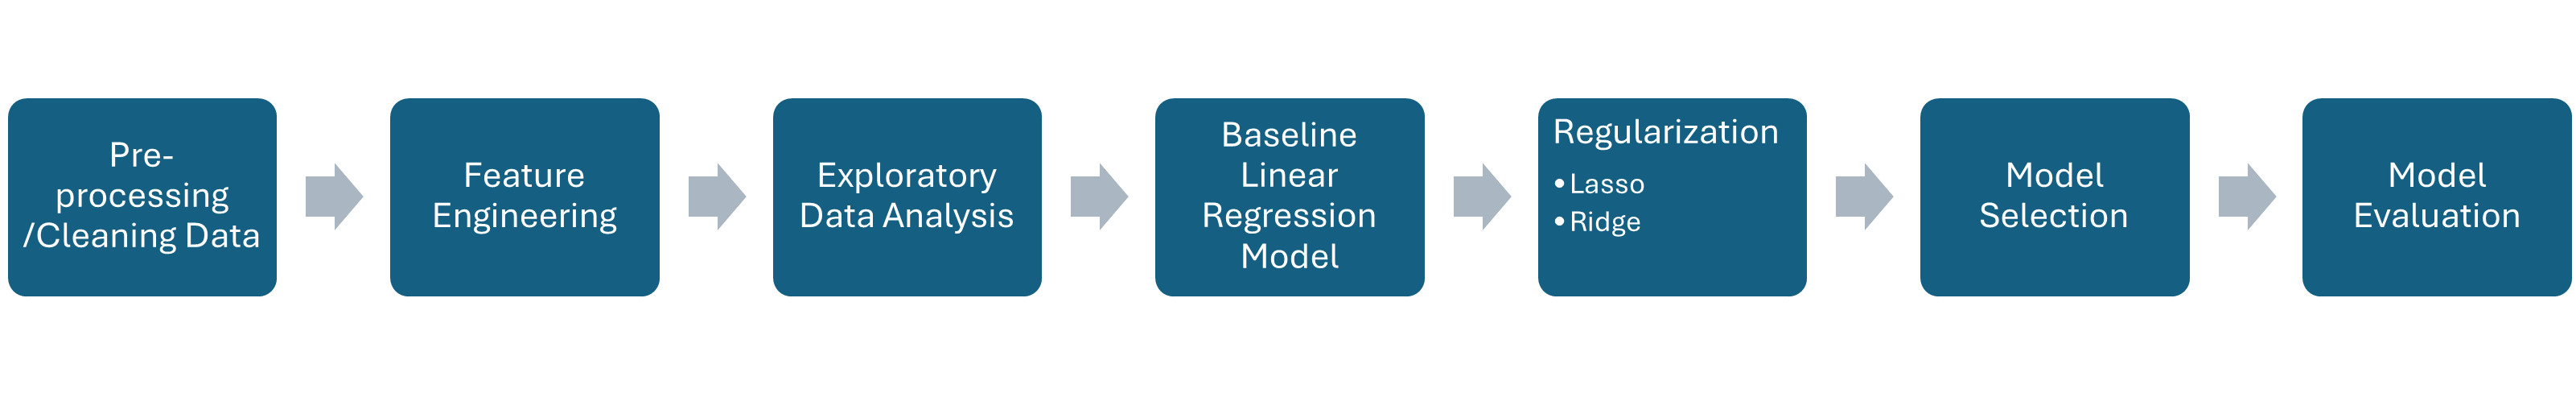

In [45]:
from IPython.display import Image
Image(filename='flowchart.png') 

<a id="setup"></a>
# Initial Setup and Pre-Processing

[Return to contents](#contents)

<a id="dataload"></a>
## Load IMDB Non-Commercial Data

In this section, we load the IMDb non-commercial datasets into pandas DataFrames for analysis. These datasets contain comprehensive information about movies, including titles, ratings, genres, crew details, and more. By importing these datasets, we set the foundation for our exploration of how the American movie market has evolved over the decades.

In [2]:
# load imdb non-commercial data
df_titleakas = pd.read_csv("data/title.akas.tsv", sep="\t")
df_titlebasics = pd.read_csv("data/title.basics.tsv", sep="\t", low_memory=False)
df_titlecrew = pd.read_csv("data/title.crew.tsv", sep="\t")
df_titleratings = pd.read_csv("data/title.ratings.tsv", sep="\t")
df_titleprincipals = pd.read_csv("data/title.principals.tsv", sep="\t")

In [3]:
df_joined = df_titlebasics.merge(df_titleakas, left_on='tconst', right_on='titleId', how='inner') \
                          .merge(df_titleratings, on='tconst', how='inner')
df_joined = df_joined.rename(columns={'titleId': 'tconst'})
df_joined.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,tconst,ordering,title,region,language,types,attributes,isOriginalTitle,averageRating,numVotes
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",tt0000001,1,Carmencita,\N,\N,original,\N,1,5.7,2108
1,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",tt0000001,2,Carmencita,DE,\N,\N,literal title,0,5.7,2108
2,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",tt0000001,3,Carmencita,US,\N,imdbDisplay,\N,0,5.7,2108
3,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",tt0000001,4,Carmencita - spanyol tánc,HU,\N,imdbDisplay,\N,0,5.7,2108
4,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",tt0000001,5,Καρμενσίτα,GR,\N,imdbDisplay,\N,0,5.7,2108


<a id="preprocessing"></a>

## Pre-Processing and Cleaning Data
To prepare the data for analysis, we perform several preprocessing and cleaning steps in this section. We merge relevant datasets to create a cohesive DataFrame that includes essential features such as movie titles, genres, ratings, and release years. We handle missing values by removing entries with empty or non-unique columns and convert necessary fields to appropriate data types. Additionally, we filter the dataset to focus exclusively on movies and organize the data into decades to facilitate a temporal analysis of trends.

In [4]:
# Replace non-numeric entries with NaN, then force to int and get rid of empties
df_joined['startYear'] = pd.to_numeric(df_joined['startYear'], errors='coerce')
df_joined2 = df_joined.dropna(subset=['startYear'])  # Drop rows where 'startYear' is NaN
df_joined2.loc[:, 'startYear'] = df_joined2['startYear'].astype(int)

# Focus on only movies
df_recentmovies = df_joined2[df_joined2['titleType'] == 'movie']

# Focus on only American region
df_recentmovies = df_recentmovies[df_recentmovies['region'] == 'US'].drop(columns=['region'])

# Remove repeats
df_recentmovies = df_recentmovies.drop_duplicates(subset=['tconst'], keep='first')

# Remove empty or not useful columns
df_recentmovies = df_recentmovies.drop(columns=['attributes', 'title', 'endYear', 'ordering', 'types', 'isOriginalTitle', 'numVotes'])
print(f'Shape of current dataframe: {df_recentmovies.shape}')

Shape of current dataframe: (184170, 11)


In [5]:
df_recentmovies.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,tconst,language,averageRating
77,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45,Romance,tt0000009,\N,5.4
764,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100,"Documentary,News,Sport",tt0000147,\N,5.2
1890,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",tt0000574,\N,6.0
1941,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90,Drama,tt0000591,\N,5.7
2048,tt0000630,movie,Hamlet,Amleto,0,1908.0,\N,Drama,tt0000630,\N,3.1


To include more predictors, we merged the datasets to include which crew members (directors, writers, actors, and actresses) worked on each movie.

In [6]:
# merge with crew dataset to get directors and writers
df_new = df_recentmovies.loc[:,~df_recentmovies.columns.duplicated()].copy()
df_new = df_new.merge(df_titlecrew, on='tconst', how='inner') #drops rows that don't have crew data
df_new = df_new.drop(
        columns=['titleType', 'primaryTitle', 'language']
    )

df_new = df_new.replace('\\N', np.nan).dropna()
print(f'Shape of current dataframe: {df_new.shape}')

Shape of current dataframe: (155670, 9)


In [7]:
df_new.head()

,tconst,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,directors,writers
0,tt0000009,Miss Jerry,0,1894.0,45,Romance,5.4,nm0085156,nm0085156
2,tt0000574,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,nm0846879,nm0846879
3,tt0000591,L'enfant prodigue,0,1907.0,90,Drama,5.7,nm0141150,nm0141150
5,tt0000679,The Fairylogue and Radio-Plays,0,1908.0,120,"Adventure,Fantasy",5.2,"nm0091767,nm0877783","nm0000875,nm0877783"
12,tt0001285,The Life of Moses,0,1909.0,50,"Biography,Drama,Family",5.5,nm0085865,"nm0676645,nm0836316"


In [8]:
# get actors and actresses in movies
df_actors = df_titleprincipals[df_titleprincipals['category'] == 'actor']
df_actresses = df_titleprincipals[df_titleprincipals['category'] == 'actress']

# only include actors in movies that are in our dataset
m = df_actors.tconst.isin(df_new.tconst)
m2 = df_actresses.tconst.isin(df_new.tconst)
df_actors = df_actors[m]
df_actress = df_actresses[m2]

# get lists of actors in each movie
df_mov_actor = df_actors.groupby('tconst')[['nconst']].agg(list)
df_mov_actress = df_actress.groupby('tconst')[['nconst']].agg(list)

df_mov_actor = df_mov_actor.reset_index()
df_mov_actor = df_mov_actor.rename(columns={"nconst": "actors_list"})

df_mov_actress = df_mov_actress.reset_index()
df_mov_actress = df_mov_actress.rename(columns={"nconst": "actresses_list"})

# merge dataset with actor lists (drops rows without actor data)
df_with_actors = df_new.merge(df_mov_actor, on='tconst', how='inner')
df_final = df_with_actors.merge(df_mov_actress, on='tconst', how='inner')

# combine actors lists into string of IDs (to mimic directors and writers)
df_final['actors'] = [','.join(map(str, l)) for l in df_final['actors_list']]
df_final['actresses'] = [','.join(map(str, l)) for l in df_final['actresses_list']]
df_final.drop(columns=['actors_list', 'actresses_list'], inplace=True)

print(f'Shape of current dataframe: {df_final.shape}')

Shape of current dataframe: (137394, 11)


In [9]:
df_final.head()

,tconst,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,directors,writers,actors,actresses
0,tt0000009,Miss Jerry,0,1894.0,45,Romance,5.4,nm0085156,nm0085156,"nm0183823,nm1309758",nm0063086
1,tt0000574,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,nm0846879,nm0846879,"nm0846894,nm1431224,nm3002376,nm0143899,nm3001...","nm0846887,nm0170118"
2,tt0000591,L'enfant prodigue,0,1907.0,90,Drama,5.7,nm0141150,nm0141150,"nm0906197,nm0332182","nm1323543,nm1759558"
3,tt0001285,The Life of Moses,0,1909.0,50,"Biography,Drama,Family",5.5,nm0085865,"nm0676645,nm0836316","nm0366742,nm0401967,nm0448682","nm0037789,nm0832458"
4,tt0001592,Ekspeditricen,0,1911.0,52,Drama,6.0,nm0088881,nm0491503,"nm0740463,nm0740463,nm0927690,nm0647719","nm0690702,nm0690702,nm0478475,nm0676978,nm1532..."


We also encoded each movie's genres as predictors. One-hot encoding wasn't enough in this case because movies can fit into multiple genres.

In [10]:
# encode main genres as predictors
main_genres = ['Action', 'Comedy', 'Drama', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Thriller']
for genre in main_genres:
    df_final[f'is{genre}'] = df_final['genres'].str.contains(genre, case=False, na=False).astype(int)

genre_pattern = '|'.join(map(re.escape, main_genres))
df_final['isOther'] = (~df_final['genres'].str.contains(genre_pattern, case=False, na=False)).astype(int)
print(f'Shape of current dataframe: {df_final.shape}')

Shape of current dataframe: (137394, 20)


In [11]:
df_final.head()

,tconst,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,directors,writers,actors,actresses,isAction,isComedy,isDrama,isFantasy,isHorror,isMystery,isRomance,isThriller,isOther
0,tt0000009,Miss Jerry,0,1894.0,45,Romance,5.4,nm0085156,nm0085156,"nm0183823,nm1309758",nm0063086,0,0,0,0,0,0,1,0,0
1,tt0000574,The Story of the Kelly Gang,0,1906.0,70,"Action,Adventure,Biography",6.0,nm0846879,nm0846879,"nm0846894,nm1431224,nm3002376,nm0143899,nm3001...","nm0846887,nm0170118",1,0,0,0,0,0,0,0,0
2,tt0000591,L'enfant prodigue,0,1907.0,90,Drama,5.7,nm0141150,nm0141150,"nm0906197,nm0332182","nm1323543,nm1759558",0,0,1,0,0,0,0,0,0
3,tt0001285,The Life of Moses,0,1909.0,50,"Biography,Drama,Family",5.5,nm0085865,"nm0676645,nm0836316","nm0366742,nm0401967,nm0448682","nm0037789,nm0832458",0,0,1,0,0,0,0,0,0
4,tt0001592,Ekspeditricen,0,1911.0,52,Drama,6.0,nm0088881,nm0491503,"nm0740463,nm0740463,nm0927690,nm0647719","nm0690702,nm0690702,nm0478475,nm0676978,nm1532...",0,0,1,0,0,0,0,0,0


We stratified the data by separating the movies by decade, starting from 1910.

In [12]:
decade_dict = {}

# limit to years after 1910
for t in range(11):
    start = (t * 10) + 1910
    
    # Create data frame for the decade
    decade_dict[t] = df_final[df_final['startYear'].between(start, start + 9)]

decades = ['1910s', '1920s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s']

<a id="featureeng"></a>
## Feature Engineering

To include more predictors, we included features based on the crew members. First, we found which crew members worked on the most movies in each decade. Then, for each decade, if a movie had a crew member from the top 5 most frequent members, we encoded that as a predictor.

In [13]:
pd.options.mode.chained_assignment = None  # default='warn'

crew_types = ['directors', 'writers', 'actors', 'actresses']

for t in range(11):
    df = decade_dict[t]

    # find most frequent crew members
    for crew in crew_types:
        crew_strings = ','.join(df[crew].to_numpy())
        crew_list = crew_strings.split(',')

        unique, counts = np.unique(crew_list, return_counts=True)
        sorted_indexes = np.argsort(counts)[::-1]
        sorted_by_freq = unique[sorted_indexes][:5]

        crew_pattern = '|'.join(map(re.escape, sorted_by_freq))

        # create binary variable if movie has most frequent member
        df[f'hasFrequent_{crew}'] = df[crew].str.contains(crew_pattern, case=False, na=False).astype(int)

    # reassign df to the updated df
    df = decade_dict[t]
    
    # compute the decade value for each row
    df['decade'] = (df['startYear'] // 10) * 10
    
    decade_dict[t] = decade_dict[t].drop(columns=['tconst', 'originalTitle',
       'genres', 'directors', 'writers', 'actors', 'actresses'])

In [14]:
decade_dict[1].head()

,isAdult,startYear,runtimeMinutes,averageRating,isAction,isComedy,isDrama,isFantasy,isHorror,isMystery,isRomance,isThriller,isOther,hasFrequent_directors,hasFrequent_writers,hasFrequent_actors,hasFrequent_actresses,decade
143,0,1925.0,80,6.6,0,1,0,0,0,0,0,0,0,0,1,0,0,1920.0
812,0,1920.0,60,5.4,1,0,1,0,0,0,1,0,0,0,0,0,0,1920.0
819,0,1920.0,60,6.6,0,1,1,0,0,0,0,0,0,0,0,0,0,1920.0
868,0,1920.0,67,8.0,0,0,0,0,1,1,0,1,0,0,0,0,0,1920.0
900,0,1920.0,60,5.3,0,0,1,0,0,0,1,0,0,0,0,0,0,1920.0


<a id="eda"></a>
# Exploratory Data Analysis
[Return to contents](#contents)

Below we pick apart the dataset and found it to be relatively well maintained. We did not have to deal with any issues of missingness and were able to pull many diagnostics from the dataset.

In [15]:
print("Basic Descriptive Statistics:")
print(df_final.describe())

Basic Descriptive Statistics:
           startYear  averageRating       isAction       isComedy  \
count  137394.000000  137394.000000  137394.000000  137394.000000   
mean     1993.968296       5.887184       0.134620       0.295384   
std        28.529584       1.273258       0.341319       0.456217   
min      1894.000000       1.000000       0.000000       0.000000   
25%      1976.000000       5.100000       0.000000       0.000000   
50%      2006.000000       6.000000       0.000000       0.000000   
75%      2016.000000       6.700000       0.000000       1.000000   
max      2024.000000      10.000000       1.000000       1.000000   

             isDrama      isFantasy       isHorror      isMystery  \
count  137394.000000  137394.000000  137394.000000  137394.000000   
mean        0.544412       0.042651       0.123149       0.064093   
std         0.498025       0.202070       0.328610       0.244920   
min         0.000000       0.000000       0.000000       0.000000   
25%

In [16]:
# print a header indicating what is being shown next
print("\nMissing values per column:")

# print the count of missing values for each column of the df
print(df_final.isna().sum())

# create a boolean series that checks for rows where both averageRating and runtimeMinutes are missing
missing_both = df_final['averageRating'].isna() & df_final['runtimeMinutes'].isna()

# print how many rows are missing both averageRating and runtimeMinutes
print("\nRows missing both averageRating and runtimeMinutes:", missing_both.sum())



Missing values per column:
tconst            0
originalTitle     0
isAdult           0
startYear         0
runtimeMinutes    0
genres            0
averageRating     0
directors         0
writers           0
actors            0
actresses         0
isAction          0
isComedy          0
isDrama           0
isFantasy         0
isHorror          0
isMystery         0
isRomance         0
isThriller        0
isOther           0
dtype: int64

Rows missing both averageRating and runtimeMinutes: 0


In [17]:
# select all columns with numeric data types from the df
numeric_cols = df_final.select_dtypes(include=[np.number]).columns

# print a header to check
print("\nCorrelation matrix for numeric columns:")

# print the correlation matrix computed only on the numeric columns
print(df_final[numeric_cols].corr())



Correlation matrix for numeric columns:
               startYear  averageRating  isAction  isComedy   isDrama  \
startYear       1.000000      -0.088765  0.030859  0.001896 -0.018048   
averageRating  -0.088765       1.000000 -0.096487  0.012552  0.244863   
isAction        0.030859      -0.096487  1.000000 -0.092288 -0.133183   
isComedy        0.001896       0.012552 -0.092288  1.000000 -0.273008   
isDrama        -0.018048       0.244863 -0.133183 -0.273008  1.000000   
isFantasy       0.036894      -0.032555  0.017953  0.005767 -0.084276   
isHorror        0.140978      -0.306333 -0.063969 -0.122339 -0.260503   
isMystery       0.020610      -0.036189 -0.060900 -0.111463 -0.037718   
isRomance      -0.093245       0.068911 -0.111523  0.119789  0.066202   
isThriller      0.156599      -0.140033  0.028965 -0.207306 -0.130575   
isOther        -0.095577       0.026029 -0.103571 -0.170021 -0.287055   

               isFantasy  isHorror  isMystery  isRomance  isThriller   isOther  
s

In [18]:
# convert the runtimeMinutes column to numeric values, coercing any invalid entries to NaN
df_final['runtimeMinutes'] = pd.to_numeric(df_final['runtimeMinutes'], errors='coerce')
df_final = df_final.dropna(subset=['runtimeMinutes'])

# calculate the first quartile 
q1 = df_final['runtimeMinutes'].quantile(0.25)

# calculate the third quartile (Q3)
q3 = df_final['runtimeMinutes'].quantile(0.75)

# compute IQR
iqr = q3 - q1

# define the lower bound for outliers
lower_bound = q1 - 1.5 * iqr

# define the upper bound for outliers
upper_bound = q3 + 1.5 * iqr

# filter the df to find rows where runtimeMinutes is outside the IQR bounds
outliers = df_final[(df_final['runtimeMinutes'] < lower_bound) | (df_final['runtimeMinutes'] > upper_bound)]

print("\nOutliers in runtimeMinutes (IQR method):")

# print the number of outlier rows found
print("Number of outliers:", len(outliers))



Outliers in runtimeMinutes (IQR method):
Number of outliers: 7702


In [19]:
# features will be used for PCA analysis
features_for_pca = ['runtimeMinutes', 'averageRating', 'isAction', 'isComedy', 'isDrama']

# select only these features from the df and remove rows with missing values
df_pca = df_final[features_for_pca].dropna()

scaler = StandardScaler()

# fit the scaler to the data and transform the features into scaled values
X_scaled = scaler.fit_transform(df_pca)

# initialize PCA with the number of components equal to the number of features
pca = PCA(n_components=len(features_for_pca))

# fit the PCA model to the scaled data
pca.fit(X_scaled)

# print the explained variance ratio for each principal component
print("\nPCA Explained Variance Ratios:")
print(pca.explained_variance_ratio_)

# print the cumulative explained variance
print("Cumulative Explained Variance:")
print(np.cumsum(pca.explained_variance_ratio_))



PCA Explained Variance Ratios:
[0.27767961 0.22646836 0.20064775 0.17519664 0.12000764]
Cumulative Explained Variance:
[0.27767961 0.50414797 0.70479572 0.87999236 1.        ]


<a id="visuals"></a>
## Visualizations

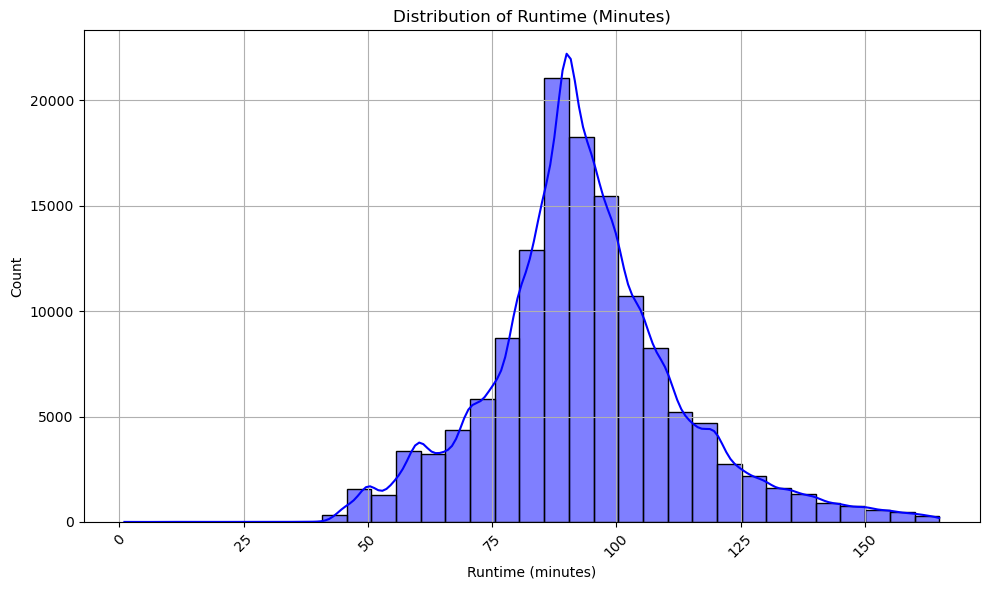

In [20]:
# calculate the 99th for runtimeMinutes to find an upper limit
upper_limit = np.percentile(df_final['runtimeMinutes'].dropna(), 99)

# filter the df to include only rows where runtimeMnutes is less than or equal to the upper limit
df_filtered = df_final[df_final['runtimeMinutes'] <= upper_limit]

plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='runtimeMinutes', kde=True, color='blue', binwidth=5)
plt.title('Distribution of Runtime (Minutes)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The histogram of runtimes shows a roughly bell shaped distribution centered around the 90–100 minute range. Most movies cluster tightly around this duration, with relatively fewer titles running significantly shorter or longer. This pattern suggest that while there is some variation, the typical American movie tends to fall near the conventional hour-and-a-half mark.

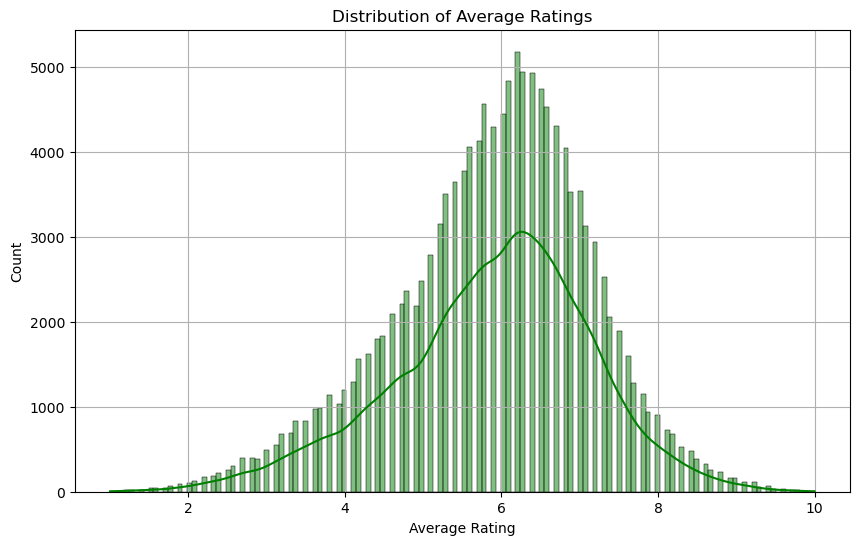

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='averageRating', kde=True, color='green')
plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.grid(True)
plt.show()

The ratings follow a generally normal distribution with a slight left skew from having more substantially bad movies. It seems audiences are pickier giving the highest ratings.

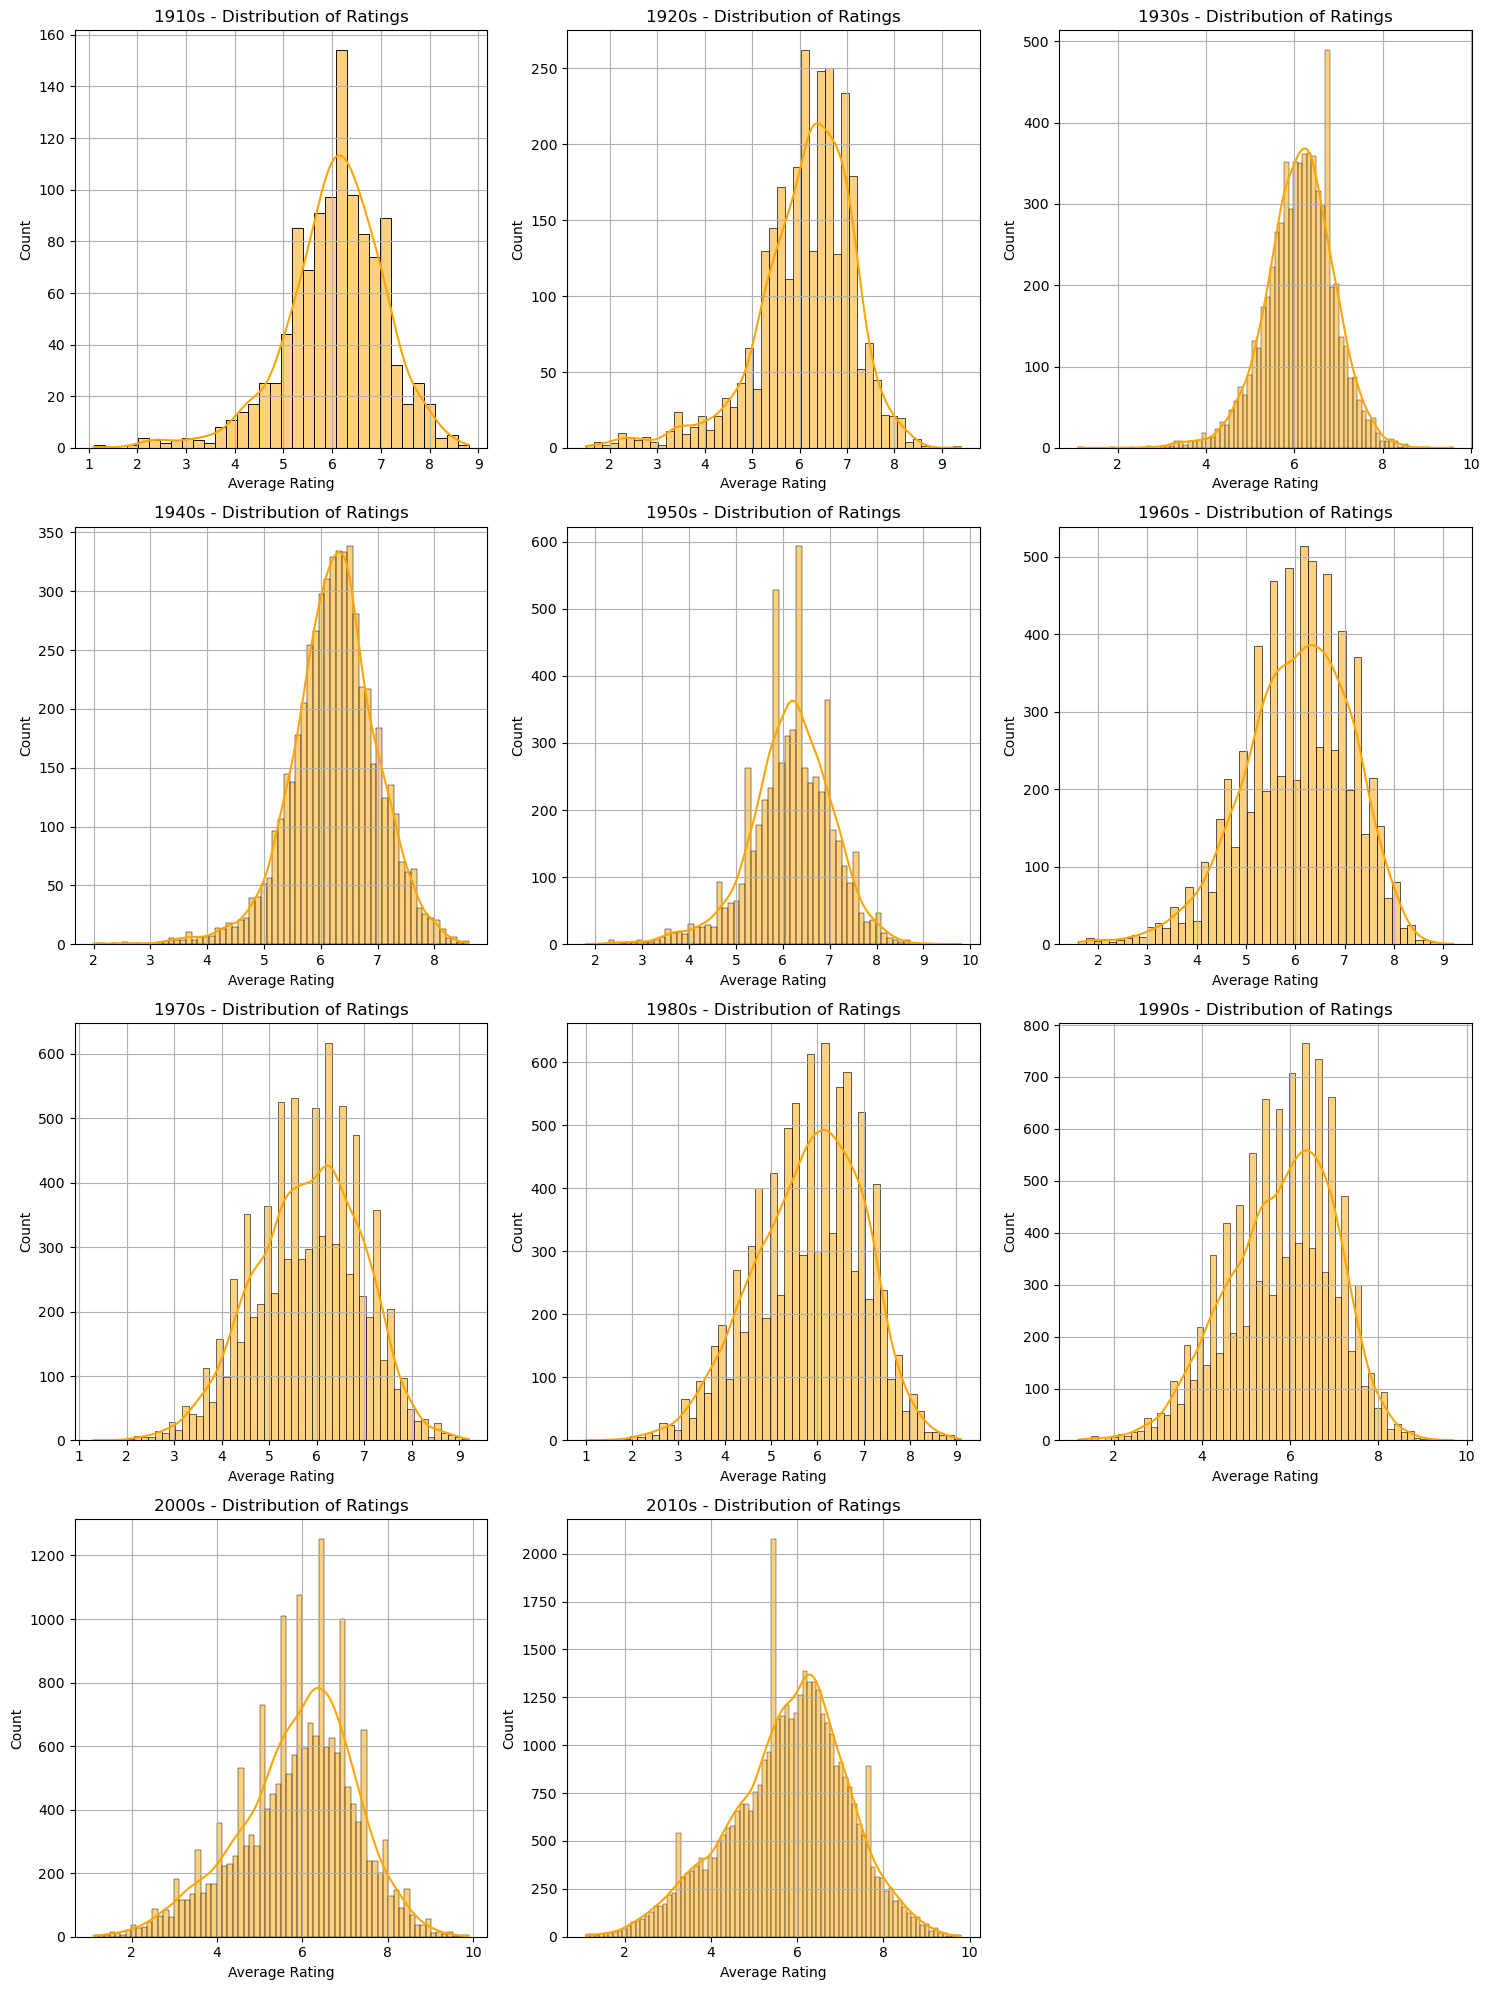

In [22]:
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

# flatten the axes array for easier indexing
axes = axes.ravel()

# loop through each decade in decade_dict along with a corresponding label from decades
for i, (t, label) in enumerate(zip(decade_dict.keys(), decades)):
    df_decade = decade_dict[t]

    # plot the distribution
    sns.histplot(data=df_decade, x='averageRating', kde=True, ax=axes[i], color='orange')

    axes[i].set_title(f'{label} - Distribution of Ratings')

    axes[i].set_xlabel('Average Rating')

    axes[i].set_ylabel('Count')

    axes[i].grid(True)

# hide unused subplots
for j in range(len(decade_dict), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Some decades show rather smooth distributions, always coming close to a normal distribution but often with a slight left skew. Later visualizations will provide more information, but these show that decades were structurally similar in ratings distributions. Some of the earlier ones seem to have much smaller standard deviations, where recent decades have a more critical spread.

C:\Users\shiba\AppData\Local\Temp\ipykernel_22252\258816494.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


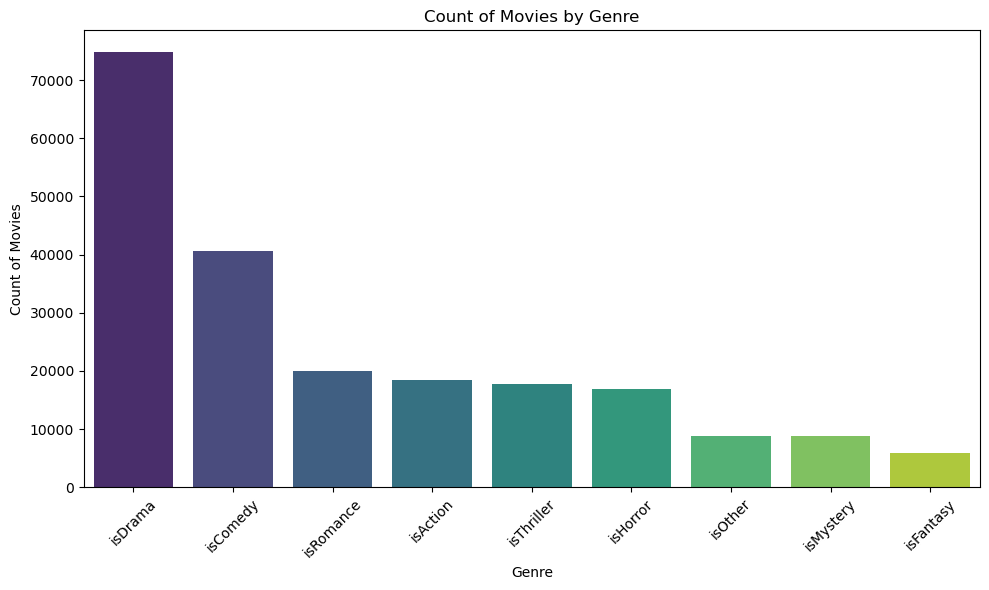

In [23]:
# define a list of columns that represent different genres as binary indicators
genre_cols = ['isAction', 'isComedy', 'isDrama', 'isFantasy', 'isHorror', 'isMystery', 'isRomance', 'isThriller', 'isOther']

# calculate the total occurrences of each genre by summing the binary columns 
# then sort them in descending order to identify the most common genres
genre_counts = df_final[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Count of Movies by Genre')
plt.xlabel('Genre')
plt.ylabel('Count of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar plot shows that drama is by far the most prevalent genre in the dataset, followed by comedy, while genres like romance, action, thriller, and horror maintain moderate representation. This distribution shows that Americans love drama, with comedic elements also being quite common.

C:\Users\shiba\AppData\Local\Temp\ipykernel_22252\4136919510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=in_genre_df, x='genre', y='averageRating', palette='Set3')


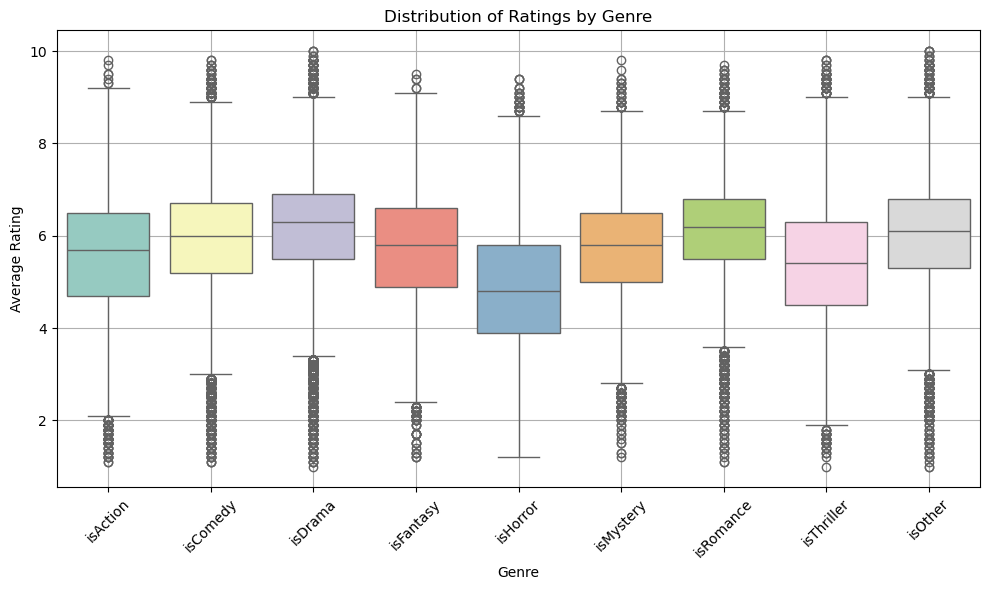

In [24]:
# this will create a row for each movie genre pair indicating if that movie is in that genre
long_genres = pd.melt(
    df_final, 
    id_vars='averageRating', 
    value_vars=genre_cols,
    var_name='genre', 
    value_name='isInGenre'
)

# filter the long df to include only rows where the movie belongs to that genre
in_genre_df = long_genres[long_genres['isInGenre'] == 1]

plt.figure(figsize=(10, 6))
sns.boxplot(data=in_genre_df, x='genre', y='averageRating', palette='Set3')
plt.title('Distribution of Ratings by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

This box plot shows that most genres cluster around relatively similar median ratings, though dramas and romances appear to achieve slightly higher medians, while horrors tend to trail lower. The range of ratings within each genre is huge, with numerous outliers at both ends, indicating a wide variability in audience reception across all categories.

In [25]:
df_all_decades = pd.concat(decade_dict.values(), ignore_index=True)

df_all_decades['runtimeMinutes'] = pd.to_numeric(df_all_decades['runtimeMinutes'], errors='coerce')
print(df_all_decades.columns)

Index(['isAdult', 'startYear', 'runtimeMinutes', 'averageRating', 'isAction',
       'isComedy', 'isDrama', 'isFantasy', 'isHorror', 'isMystery',
       'isRomance', 'isThriller', 'isOther', 'hasFrequent_directors',
       'hasFrequent_writers', 'hasFrequent_actors', 'hasFrequent_actresses',
       'decade'],
      dtype='object')


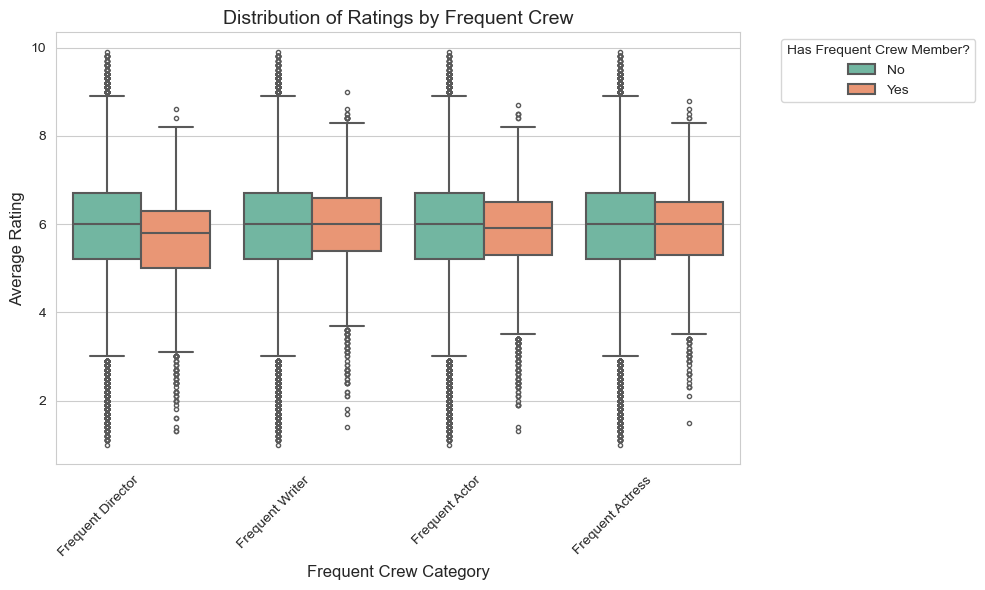

In [26]:
# concatejnate all df in decade_dict into a single df
df_all_decades = pd.concat(decade_dict.values(), ignore_index=True)

# convert runtimeMinutes to a numeric
df_all_decades['runtimeMinutes'] = pd.to_numeric(df_all_decades['runtimeMinutes'], errors='coerce')

# define the list of frequent crew flag columns
crew_flags = ['hasFrequent_directors', 'hasFrequent_writers', 'hasFrequent_actors', 'hasFrequent_actresses']

# melt the df from wide to long format to facilitate grouped plotting
melted = pd.melt(df_all_decades, 
                 id_vars='averageRating', 
                 value_vars=crew_flags,
                 var_name='crew_flag', 
                 value_name='flag_value')

# create a copy of the melted df for formatting the crew_flag names
melted_formatted = melted.copy()

# map the original crew_flag column names to more readable categories
category_map = {
    'hasFrequent_directors': 'Frequent Director',
    'hasFrequent_writers': 'Frequent Writer',
    'hasFrequent_actors': 'Frequent Actor',
    'hasFrequent_actresses': 'Frequent Actress'
}
melted_formatted['crew_flag'] = melted_formatted['crew_flag'].replace(category_map)

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# plot a boxplot of averageRating grouped by crew_flag category and differentiated by flag_value
ax = sns.boxplot(data=melted_formatted, x='crew_flag', y='averageRating', hue='flag_value', 
                 palette='Set2', fliersize=3, linewidth=1.5)

plt.title('Distribution of Ratings by Frequent Crew', fontsize=14)
plt.xlabel('Frequent Crew Category', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

# readability fixes
plt.xticks(rotation=45, ha='right')
handles, labels = ax.get_legend_handles_labels()
label_map = {'0': 'No', '1': 'Yes'}

labels = [label_map.get(l, l) for l in labels]
ax.legend(handles, labels, title='Has Frequent Crew Member?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


The box plot indicaes that having frequently working directors, writers, actors, or actresses involved does not dramatically shift the overall rating distribution. Across all categories, the medians and spreads are relatively similar, indicating that films with or without these frequent crew members achieve comparable audience ratings.

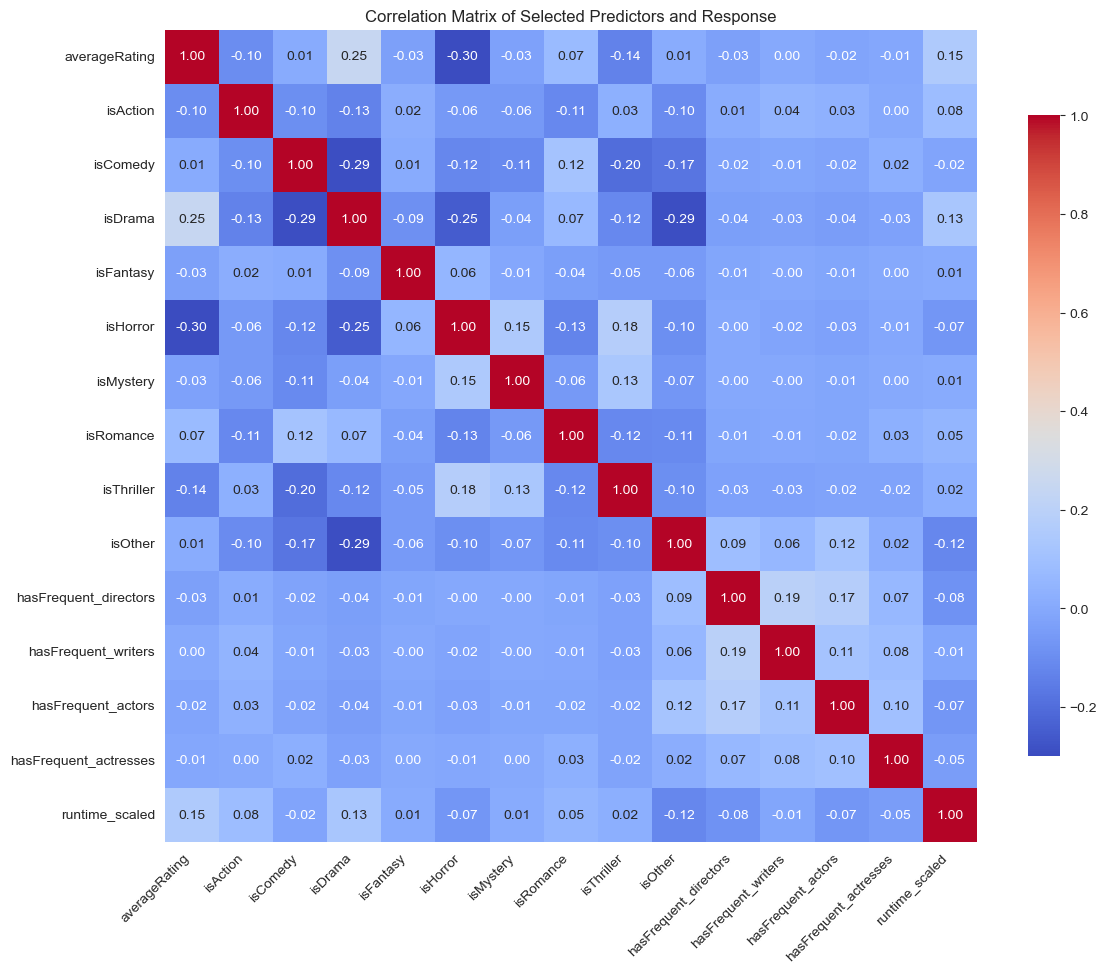

In [27]:
features = [
    'averageRating', 'runtimeMinutes', 
    'isAction', 'isComedy', 'isDrama', 'isFantasy', 'isHorror', 'isMystery', 'isRomance', 'isThriller', 'isOther',
    'hasFrequent_directors', 'hasFrequent_writers', 'hasFrequent_actors', 'hasFrequent_actresses'
]

# check all features exist in df_all_decades
for col in features:
    if col not in df_all_decades.columns:
        print(f"Column {col} not found in df_all_decades. Please ensure all columns are present.")

# create a new df for correlation analysis
df_corr = df_all_decades[features].dropna()

scaler = StandardScaler()

# add a new column runtime_scaled after scaling
df_corr['runtime_scaled'] = scaler.fit_transform(df_corr[['runtimeMinutes']])

# drop the original runtimeMinutes column
df_corr.drop(columns=['runtimeMinutes'], inplace=True)

# correlation matrix for the df
corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .75})
plt.title('Correlation Matrix of Selected Predictors and Response')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The PCA chart suggests that there is rarely any correlation between averageRating and the other predictors. The strongest is its correlation with "isDrama." As you'll see in the blue and orange histogram at the bottom of this section "Genre Prevalence in Top vs. Bottom 1% Rated Movies, there's a substantial difference in dramas and other genres in terms of their prevelance in the top 1% (with horror being the most common genre in the bottom 1%). Both of these findings suggest dramas do better in imdb ratings. However, as we see in the above histogram "Count of Movies by Genre," this finding is likely confounded by drama being the most populated category. In the box and whisker plot "Distribution of Ratings by Genre," we see that drama's only have a slight edge over romance and fantasy.

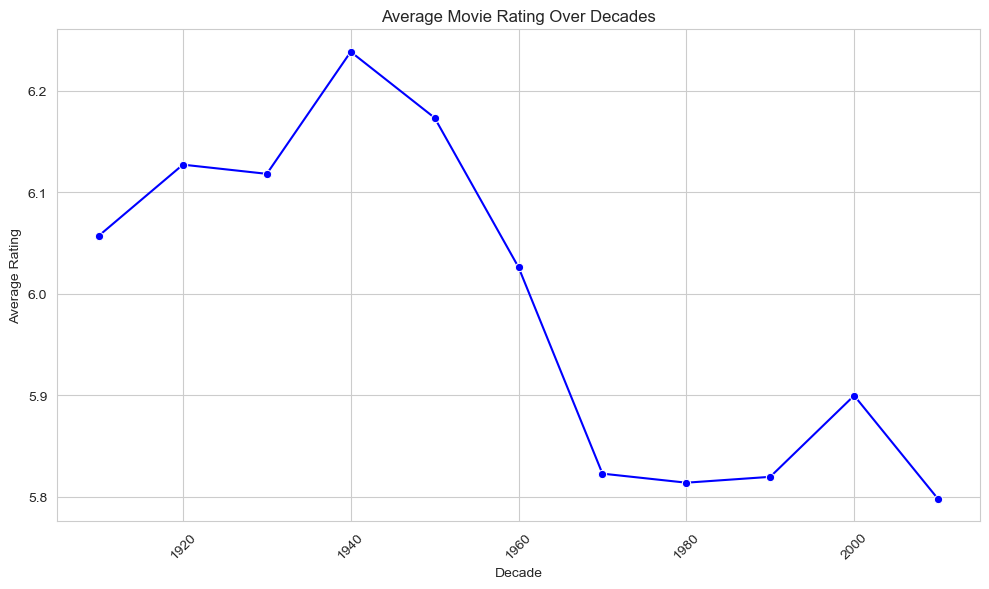

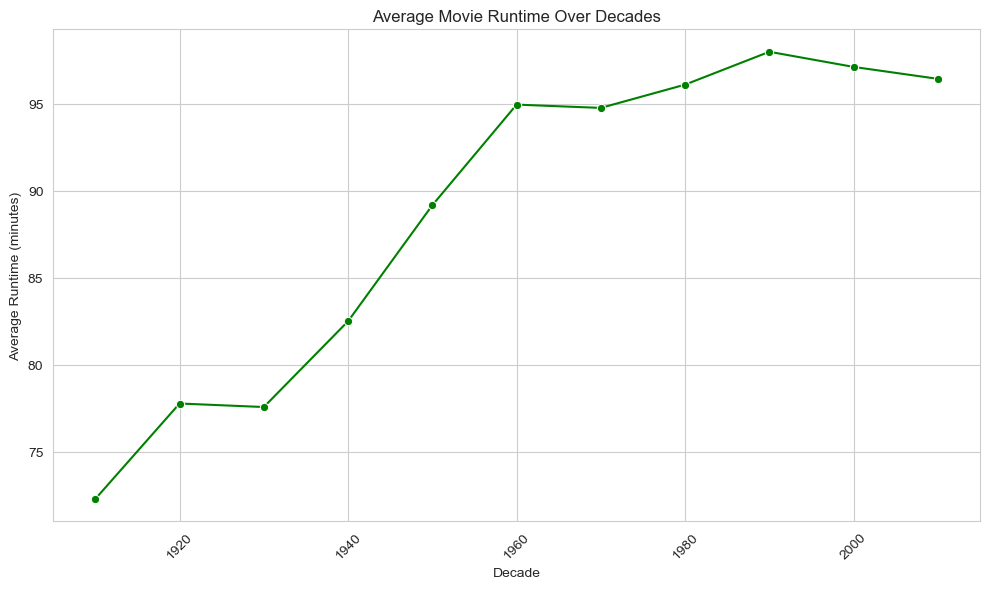

In [28]:
# create a copy of df_all_decades to save the original data
df_decade_stats = df_all_decades.copy()

# compute a decade column by taking the floor of startYear/10 and multiplying by 10
df_decade_stats['decade'] = (df_decade_stats['startYear'] // 10) * 10

# compute mean averageRating and mean runtimeMinutes
df_decade_stats = (
    df_decade_stats.groupby('decade')
    .agg(
        avg_rating=('averageRating', 'mean'),
        avg_runtime=('runtimeMinutes', 'mean')
    )
    .reset_index()
)

# average rating decades
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_decade_stats, x='decade', y='avg_rating', marker='o', color='blue')
plt.title('Average Movie Rating Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# average runtime decades
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_decade_stats, x='decade', y='avg_runtime', marker='o', color='green')
plt.title('Average Movie Runtime Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

The upward trajectory in average runtime suggests that filmmakers have increasingly embraced longer storytelling formats over the past century. However, audiences’ ratings do not track this trend: after reaching a mid century peak, ratings gradually declined and then leveled off at a lower plateau in recent decades. This divergence implies that while movies grew longer, perhaps due to changes in filmmaking style, production practices, etc. this additional runtime did not translate into sustained improvements in viewer reception.

C:\Users\shiba\AppData\Local\Temp\ipykernel_22252\3174823702.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='isAdult', y='averageRating', palette='Set2')


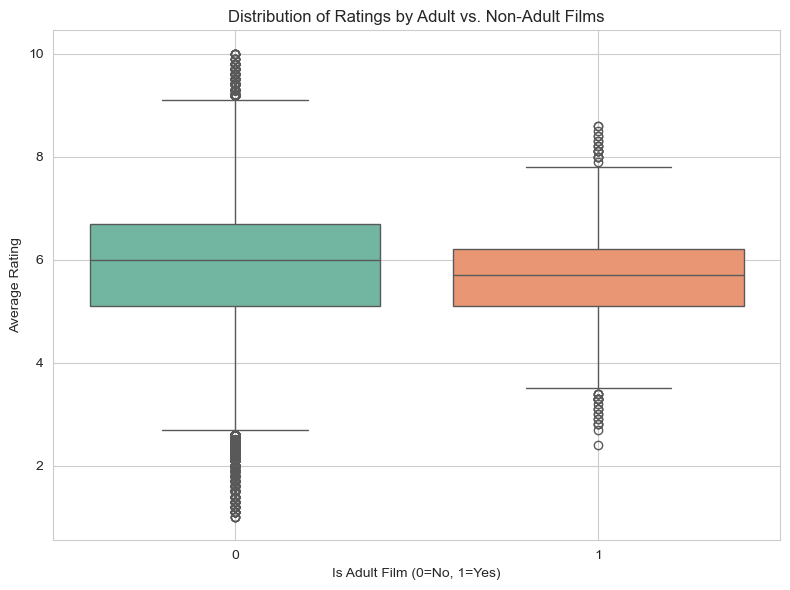

C:\Users\shiba\AppData\Local\Temp\ipykernel_22252\3174823702.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='isAdult', y='averageRating', palette='Set3', inner='quartile')


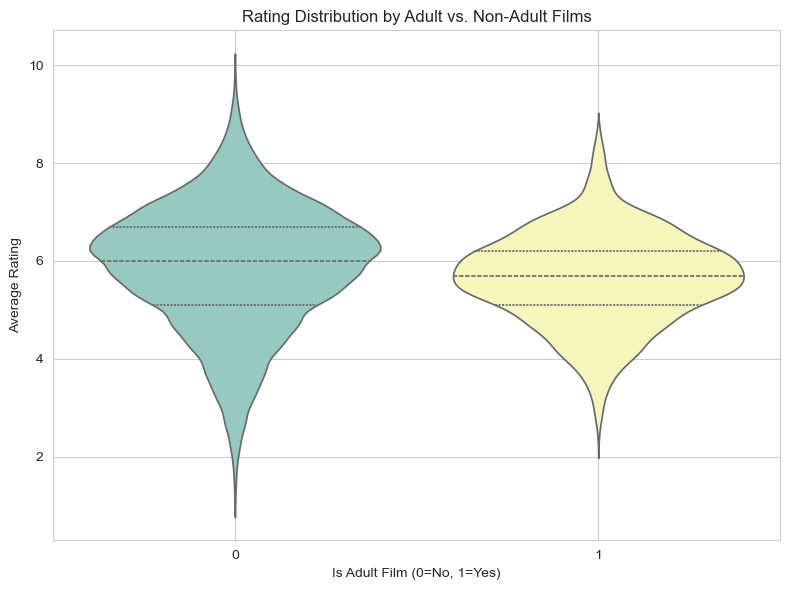

In [29]:
if 'isAdult' in df_final.columns:
    df_final['isAdult'] = pd.to_numeric(df_final['isAdult'], errors='coerce').fillna(0).astype(int)
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_final, x='isAdult', y='averageRating', palette='Set2')
    plt.title('Distribution of Ratings by Adult vs. Non-Adult Films')
    plt.xlabel('Is Adult Film (0=No, 1=Yes)')
    plt.ylabel('Average Rating')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df_final, x='isAdult', y='averageRating', palette='Set3', inner='quartile')
    plt.title('Rating Distribution by Adult vs. Non-Adult Films')
    plt.xlabel('Is Adult Film (0=No, 1=Yes)')
    plt.ylabel('Average Rating')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

The distributions suggest that adult films tend to receive slightly lower median ratings than their non adult ones, with more compressed clusters around the lower-middle rating range. While both categories exhibit a wide range of audience evaluations, non adult movies appear more likely to achieve higher marks and less likely to cluster at the low end. This pattern implies that, on average, mainstream films garner broader appeal and more favorable audience perceptions, whereas adult films may face more polarized or tepid receptions, potentially reflecting their niche appeal and differing production values.

=== Bottom 1% Outliers ===
Rating <= 2.60
Count: 1299
    isAdult  startYear  runtimeMinutes  averageRating  isAction  isComedy  \
112       0     1914.0             310            2.4         0         0   
238       0     1915.0              50            2.2         0         0   
311       0     1916.0              50            2.2         0         0   
572       0     1919.0              50            2.4         0         1   
573       0     1918.0              50            2.2         0         0   

     isDrama  isFantasy  isHorror  isMystery  isRomance  isThriller  isOther  \
112        0          0         0          0          0           0        1   
238        0          0         0          0          0           0        1   
311        1          0         0          0          0           0        0   
572        0          0         0          0          0           0        0   
573        0          1         0          0          0           0        0   

  

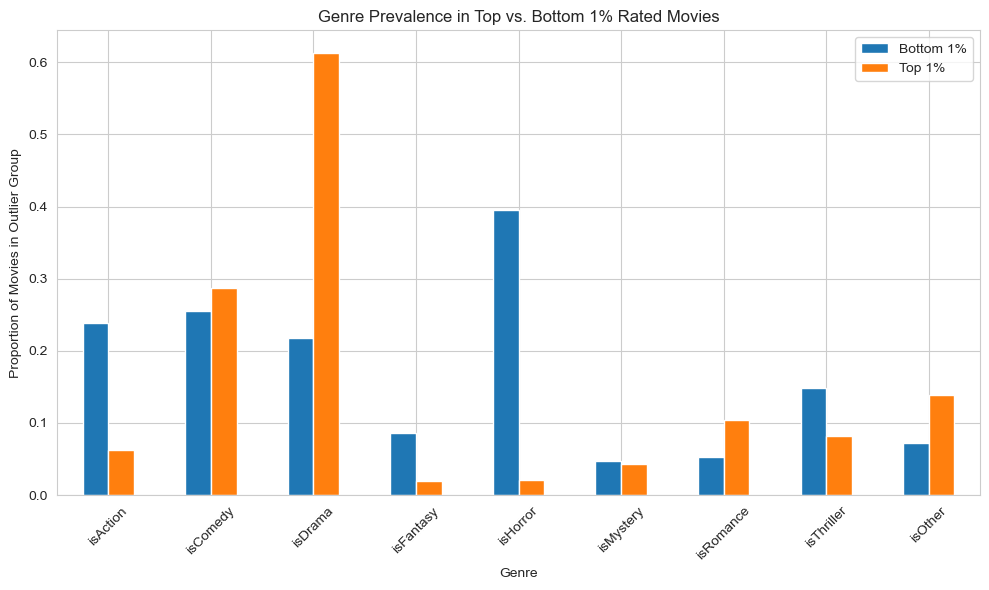

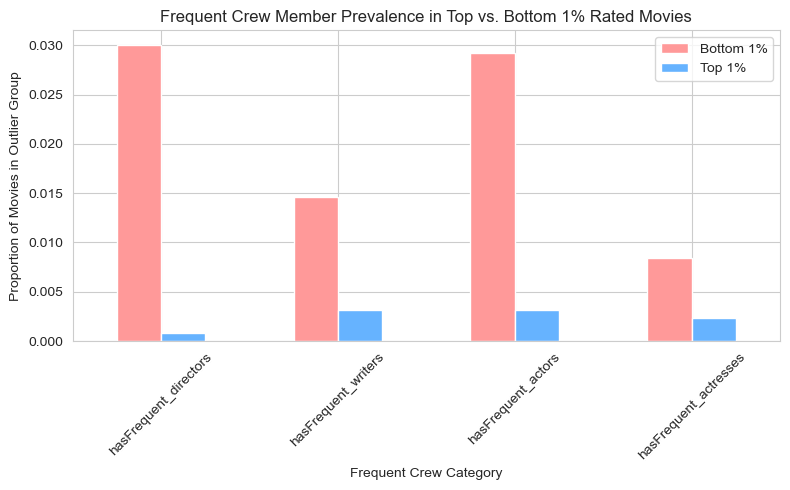

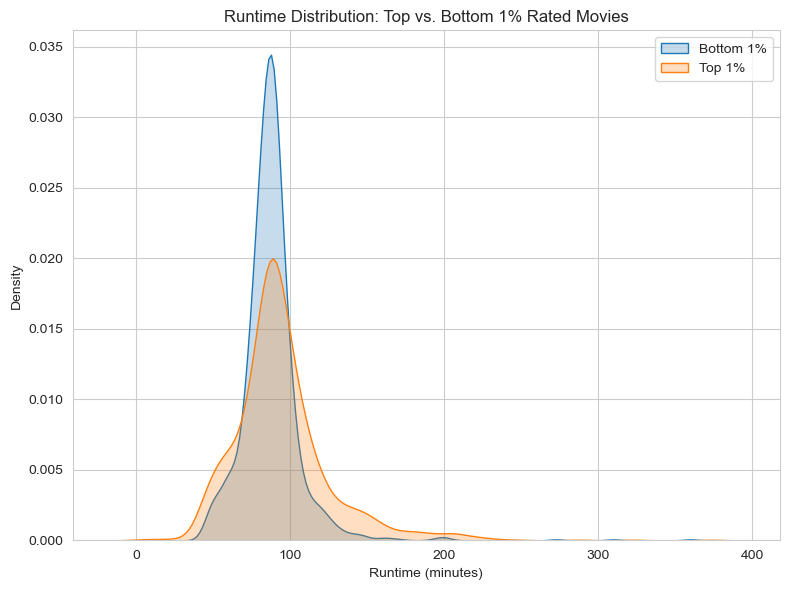

In [30]:
# create a copy of the df for inspection
df_inspect = df_all_decades.copy()

df_inspect['runtimeMinutes'] = pd.to_numeric(df_inspect['runtimeMinutes'], errors='coerce')

# drop rows that have missing values
df_inspect = df_inspect.dropna(subset=['runtimeMinutes'])

# determine the low and high thresholds for outliers based on the averageRating distribution
low_threshold = np.percentile(df_inspect['averageRating'], 1)
high_threshold = np.percentile(df_inspect['averageRating'], 99)

# select the bottom 1%
bottom_outliers = df_inspect[df_inspect['averageRating'] <= low_threshold]

# now top 1% 
top_outliers = df_inspect[df_inspect['averageRating'] >= high_threshold]

# print information about the bottom 1%
print("=== Bottom 1% Outliers ===")
print(f"Rating <= {low_threshold:.2f}")
print(f"Count: {len(bottom_outliers)}")
print(bottom_outliers.head())

# now top 1%
print("\n=== Top 1% Outliers ===")
print(f"Rating >= {high_threshold:.2f}")
print(f"Count: {len(top_outliers)}")
print(top_outliers.head())

# calculate the mean of genre indicators for bottom and top
bottom_genre_means = bottom_outliers[genre_cols].mean()
top_genre_means = top_outliers[genre_cols].mean()

# create a df to compare genre prevalence
genre_df = pd.DataFrame({
    'Bottom 1%': bottom_genre_means,
    'Top 1%': top_genre_means
})

# plot a bar chart for genre prevalence
genre_df.plot(kind='bar', figsize=(10,6), rot=45)
plt.title('Genre Prevalence in Top vs. Bottom 1% Rated Movies')
plt.xlabel('Genre')
plt.ylabel('Proportion of Movies in Outlier Group')
plt.tight_layout()
plt.grid(True)
plt.show()

crew_flags = ['hasFrequent_directors', 'hasFrequent_writers', 'hasFrequent_actors', 'hasFrequent_actresses']

available_crew_flags = [c for c in crew_flags if c in df_inspect.columns]

if available_crew_flags:
    bottom_crew_means = bottom_outliers[available_crew_flags].mean()
    top_crew_means = top_outliers[available_crew_flags].mean()

    crew_df = pd.DataFrame({
        'Bottom 1%': bottom_crew_means,
        'Top 1%': top_crew_means
    })

    # plot a bar chart to visualize crew prevalence
    crew_df.plot(kind='bar', figsize=(8,5), rot=45, color=['#FF9999', '#66B3FF'])
    plt.title('Frequent Crew Member Prevalence in Top vs. Bottom 1% Rated Movies')
    plt.xlabel('Frequent Crew Category')
    plt.ylabel('Proportion of Movies in Outlier Group')
    plt.tight_layout()
    plt.grid(True)
    plt.show()
else:
    print("Frequent crew member columns are not present. Skipping crew comparison plots.")

# compare the runtime distribution between top and bottom outliers using KDE
plt.figure(figsize=(8,6))
sns.kdeplot(data=bottom_outliers, x='runtimeMinutes', fill=True, label='Bottom 1%')
sns.kdeplot(data=top_outliers, x='runtimeMinutes', fill=True, label='Top 1%')
plt.title('Runtime Distribution: Top vs. Bottom 1% Rated Movies')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


- **Plot 1:** The comparison between top and bottom 1% rated films highlights genre contrasts: dramas dominate among the top performers, while horrors are disproportionately represented at the low end. This suggests that films achieving exceptional acclaim are more likely to emphasize dramatic narratives, whereas those eliciting particularly negative responses often lean toward the horror category.

- **Plot 2:** This visualization suggests that movies featuring the most frequently working directors, writers, actors, and actresses are more prevalent among the bottom 1% of rated titles than among the top 1%. In other words, having these repeatedly involved crew members does not necessarily translate into critical acclaim. Instead, it appears that such frequent participation might be associated with lower audience reception, so that simply reusing familiar creative personnel may not guarantee quality or broad appeal.

- **Plot 3:** While bottom 1% rated movies cluster tightly around a conventional feature runtime, the top 1% rated films show a broader, more flexible distribution that occasionally extends to both shorter and longer runtimes. Perhaps exceptional audience reception may be less about conforming to a standard runtime and more about effectively using whichever length best serves the storytelling.

<a id="modeling"></a>
# Modeling
[Return to contents](#contents)

Since our response variable was a continuous variable, we chose to use linear models to predict average IMDb rating from the features in our data. We also knew linear regression would be a good baseline model, since it can be improved in many ways including adding polynomial features and regularization. 

Below is a function to extract the metrics from a given model. This function made it easier to evaluate each model without having to replicate code.

In [31]:
def get_metrics(ind, model, name: str, kf, data: tuple) -> dict:    
    '''
       returns a dictionary of metrics for a given model including, train MSE, test MSE, cross-validated MSE,
       and train and test r2 scores.

       input: index for decade number, model, model name, KFold object, data
       output: dictionary of model metrics
    '''
    d = {}

    X_train, X_test, y_train, y_test = data

    y_train_preds = model.predict(X_train)
    y_test_preds = model.predict(X_test)

    d['decade_ind'] = ind
    d['name'] = name

    # store mses
    d['train_mse'] = [mean_squared_error(y_train, y_train_preds)]
    d['test_mse'] = [mean_squared_error(y_test, y_test_preds)]

    # store cross-validated mse
    cv_mses = cross_validate(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    d['avg_cv_mse'] = [-1*np.mean(cv_mses['test_score'])]

    # store r2 scores
    d['r2_train'] = [model.score(X_train, y_train)]
    d['r2_test'] = [model.score(X_test, y_test)]

    return d

We treated each decade as a new dataset and fit 3 models to each dataset: Linear Regression, Linear Regression with Lasso Regularization, and Linear Regression with Ridge Regularization. With 11 decades, we ended up with 33 models. 

Before fitting each model, we decided to scale runtime so that its coefficient is not affected by its scale and because the other predictors are binary. We split the data into training and testing, fit each model to the training data, cross-validated each model, and finally stored the coefficients and metrics.

The alpha penalty term for lasso and ridge regularization was chosen through cross validation.

In [32]:
lr_coefs_dec = []
lasso_coefs_dec = []
ridge_coefs_dec = []

best_lasso_alphas = []
best_ridge_alphas = []

scaler = StandardScaler()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

results_df = pd.DataFrame()

for t in range(11):
    df = decade_dict[t]

    # scale runtime 
    df['runtime_scaled'] = scaler.fit_transform(df['runtimeMinutes'].values.reshape(-1,1))

    # split training and testing data
    X = df.drop(columns=['averageRating', 'runtimeMinutes', 'startYear', 'decade'])
    y = df['averageRating']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    data = (X_train, X_test, y_train, y_test)

    # linear regression
    # linear regression fit
    lr.fit(X_train, y_train)

    # store coefficients
    lr_coef = dict(zip(X_train.columns, np.transpose(lr.coef_)))
    lr_coefs_dec.append(lr_coef)

    # get metrics in dictionary
    lr_d = get_metrics(t, lr, 'Linear Regression', kf, data)
    results_df = pd.concat([results_df, (pd.DataFrame(lr_d))])
                                            
    # regularization with best alpha
    alphas = [10**-5, 10**-4, 10**-3, 10**-2, 10**-1]

    # lasso CV to find alpha
    lassoCV = LassoCV(alphas=alphas, random_state=42)
    lassoCV.fit(X_train, y_train)
    best_lasso_alpha = lassoCV.alpha_
    best_lasso_alphas.append(best_lasso_alpha)

    # fit with best alpha
    lasso = Lasso(alpha=best_lasso_alpha, random_state=42)
    lasso.fit(X_train, y_train)

    # store coefficients
    lasso_coef = dict(zip(X_train.columns, np.transpose(lasso.coef_)))
    lasso_coefs_dec.append(lasso_coef)

    # get metrics in dictionary
    lasso_d = get_metrics(t, lasso, 'Lasso Regression', kf, data)
    results_df = pd.concat([results_df, (pd.DataFrame(lasso_d))])

    # ridge CV to find alpha
    ridgeCV = RidgeCV(alphas=alphas)
    ridgeCV.fit(X_train, y_train)
    best_ridge_alpha = ridgeCV.alpha_
    best_ridge_alphas.append(best_ridge_alpha)

    # fit with best alpha
    ridge = Ridge(alpha=best_ridge_alpha)    
    ridge.fit(X_train, y_train)

    # store coefficients
    ridge_coef = dict(zip(X_train.columns, np.transpose(ridge.coef_)))
    ridge_coefs_dec.append(ridge_coef)
    
    # get metrics in dictionary
    ridge_d = get_metrics(t, ridge, 'Ridge Regression', kf, data)
    results_df = pd.concat([results_df, (pd.DataFrame(ridge_d))])

In [33]:
results_df.head()

,decade_ind,name,train_mse,test_mse,avg_cv_mse,r2_train,r2_test
0,0,Linear Regression,0.977134,1.030912,1.005564,0.053984,0.040320
0,0,Lasso Regression,0.989799,1.042039,1.005385,0.041722,0.029961
0,0,Ridge Regression,0.977134,1.030859,1.005478,0.053984,0.040369
0,1,Linear Regression,0.939209,1.154014,0.953894,0.071993,0.058153
0,1,Lasso Regression,0.939472,1.154619,0.953586,0.071733,0.057659


<a id="plotting"></a>
# Plot Results
[Return to contents](#contents)

To evaluate our models and compare results we visualized the metrics and coefficients of each model.

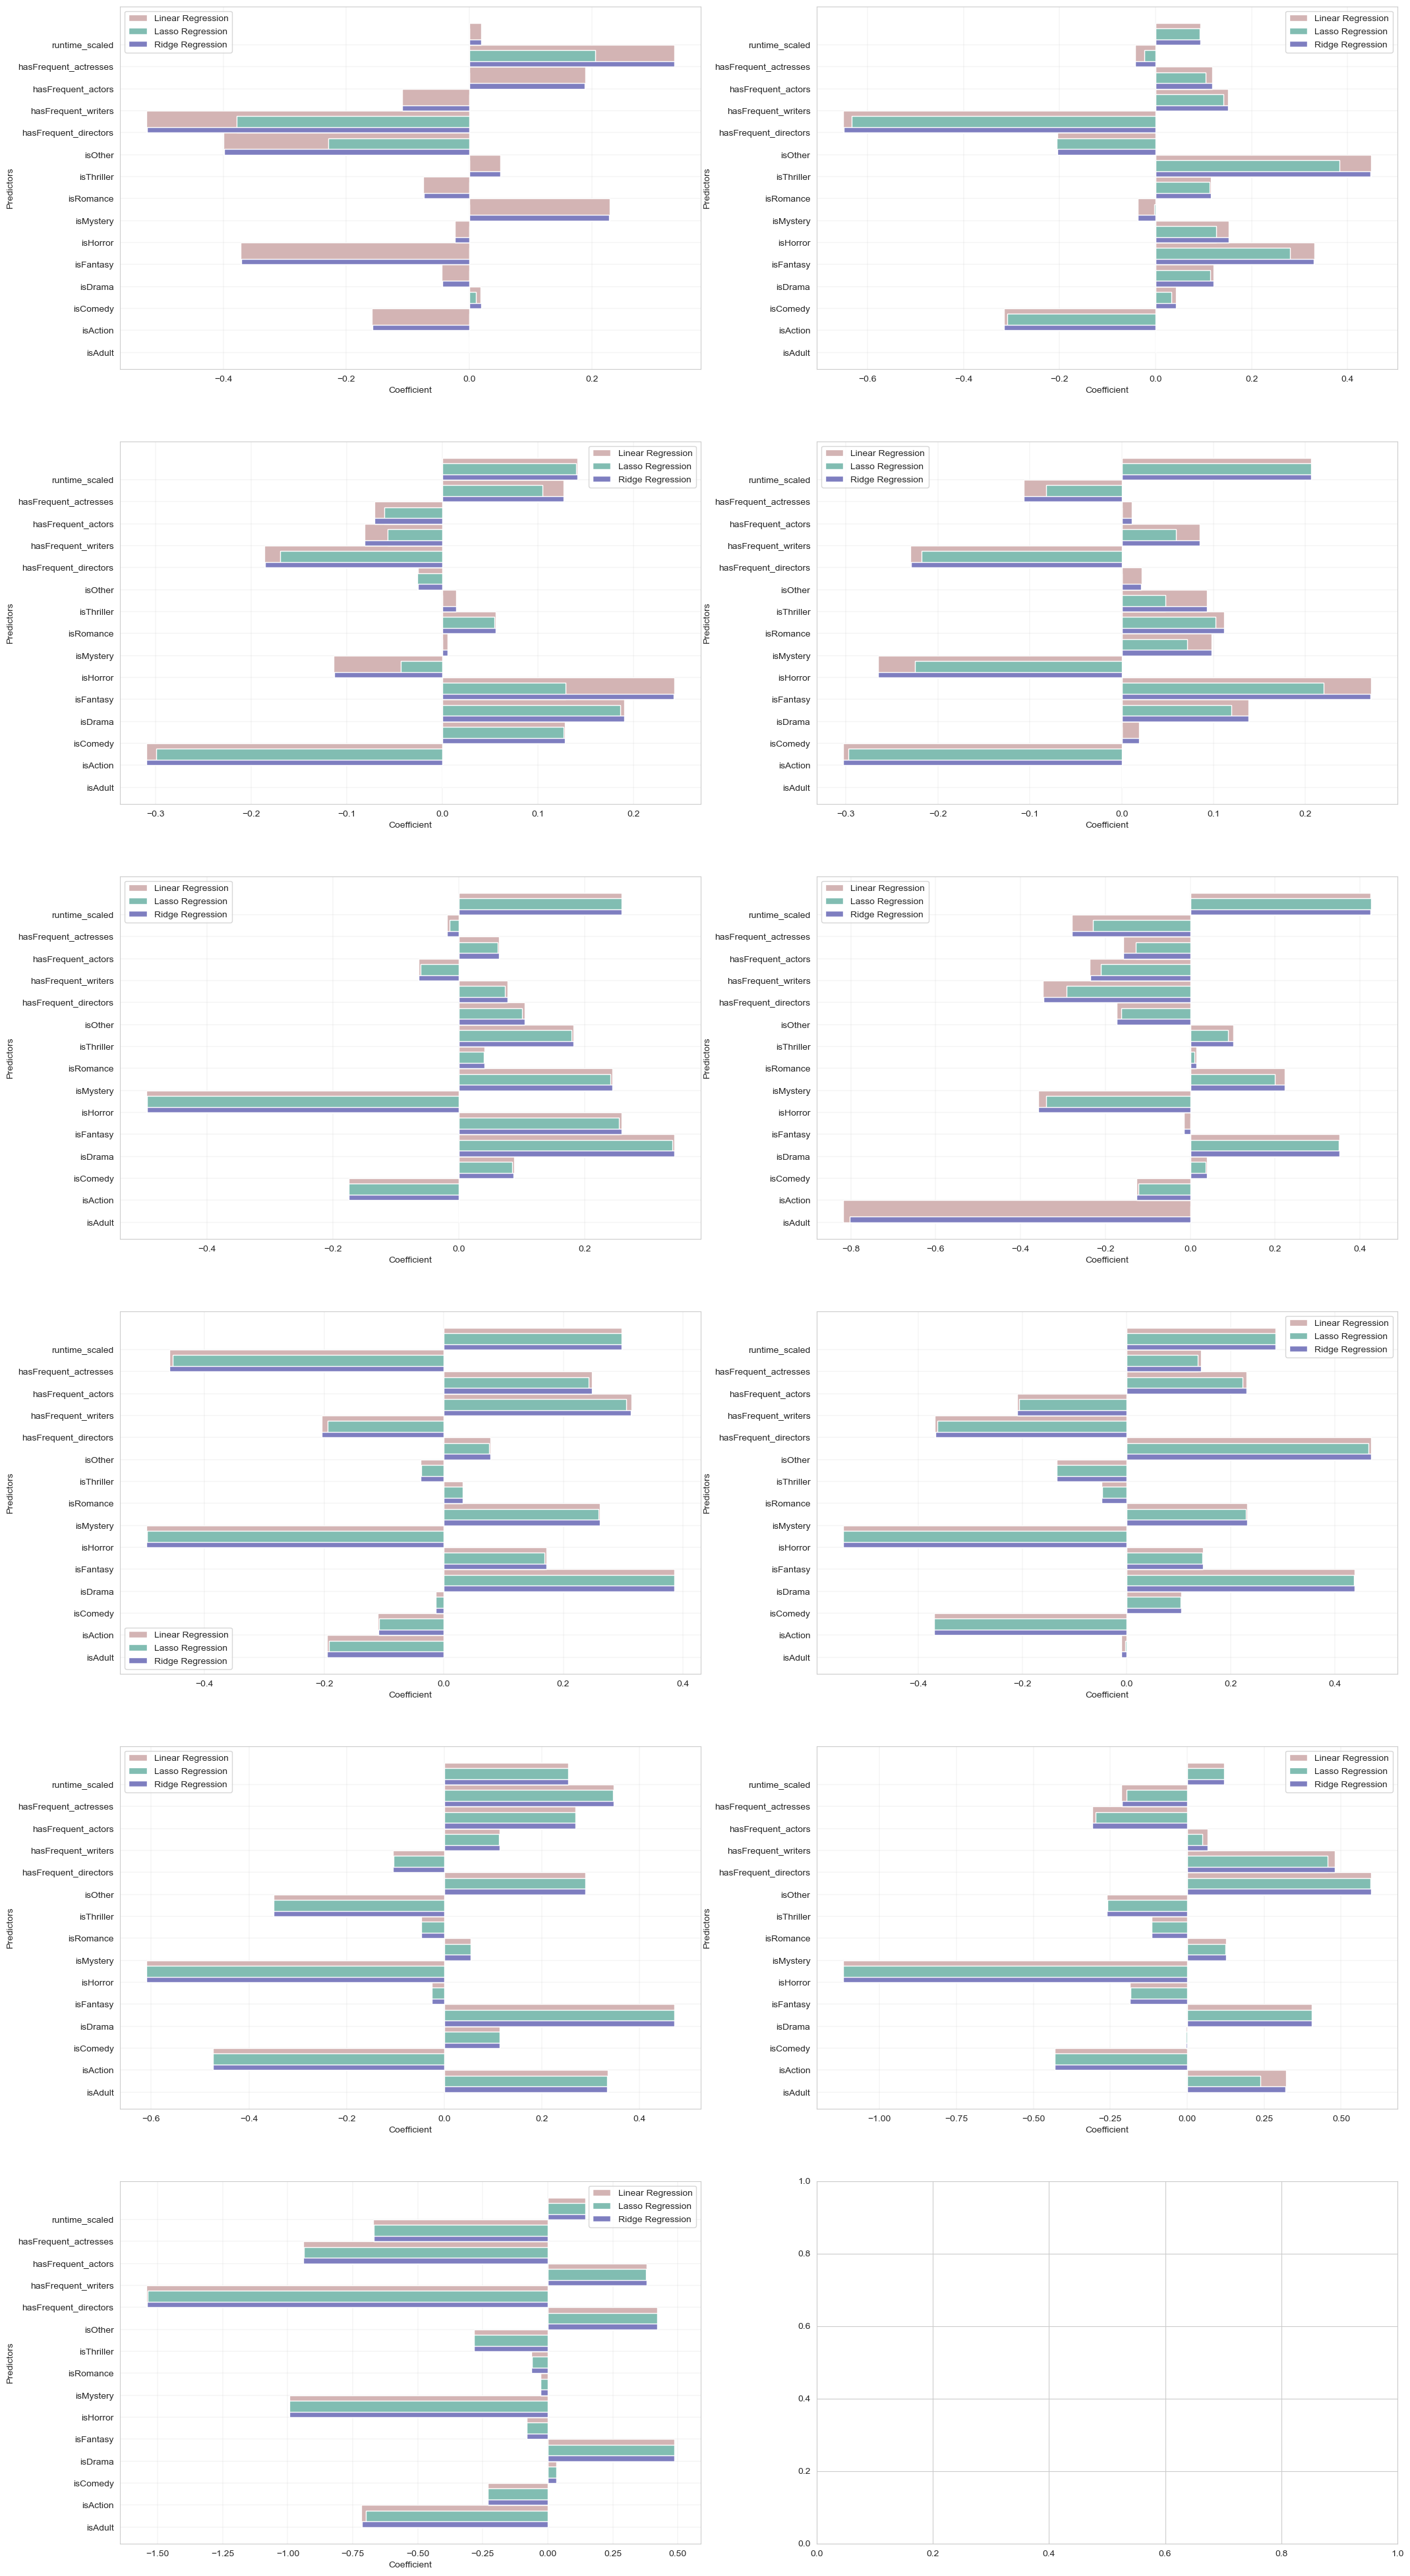

In [34]:
fig, axes = plt.subplots(6, 2, figsize=(25, 50))
axes = axes.ravel()

for t in range(11):
    lr_x = list(lr_coefs_dec[t].keys())
    lr_y = list(lr_coefs_dec[t].values())

    lasso_x = list(lasso_coefs_dec[t].keys())
    lasso_y = list(lasso_coefs_dec[t].values())
    
    ridge_x = list(ridge_coefs_dec[t].keys())
    ridge_y = list(ridge_coefs_dec[t].values())

    # for each decade plot coefficients of each model
    axes[t].barh(lr_x,lr_y, 1.0, align='edge',color="#D3B4B4", label="Linear Regression")
    axes[t].barh(lasso_x,lasso_y, 0.75 ,align='edge',color="#81BDB2",label = "Lasso Regression")
    axes[t].barh(ridge_x,ridge_y, 0.25 ,align='edge',color="#7E7EC0", label="Ridge Regression")

    axes[t].grid(linewidth=0.2)
    axes[t].set_xlabel("Coefficient")
    axes[t].set_ylabel("Predictors")
    axes[t].legend(loc='best')

Across the decades, each predictor’s influence on movie ratings is relatively modest. No single feature stands out as a strong or consistent driver of ratings, and the direction and magnitude of coefficients vary slightly without forming a clear pattern. The similarity of the three bars within each predictor suggests that regularization does not dramatically change coefficient estimates relative to plain linear regression. The chosen predictors, runtime and genre indicators, as well as flags for frequent directors, writers, actors, and actresses, do not provide robust explanatory power. The nearly identical results across models imply that these basic features are not strongly related to the final IMDb ratings.

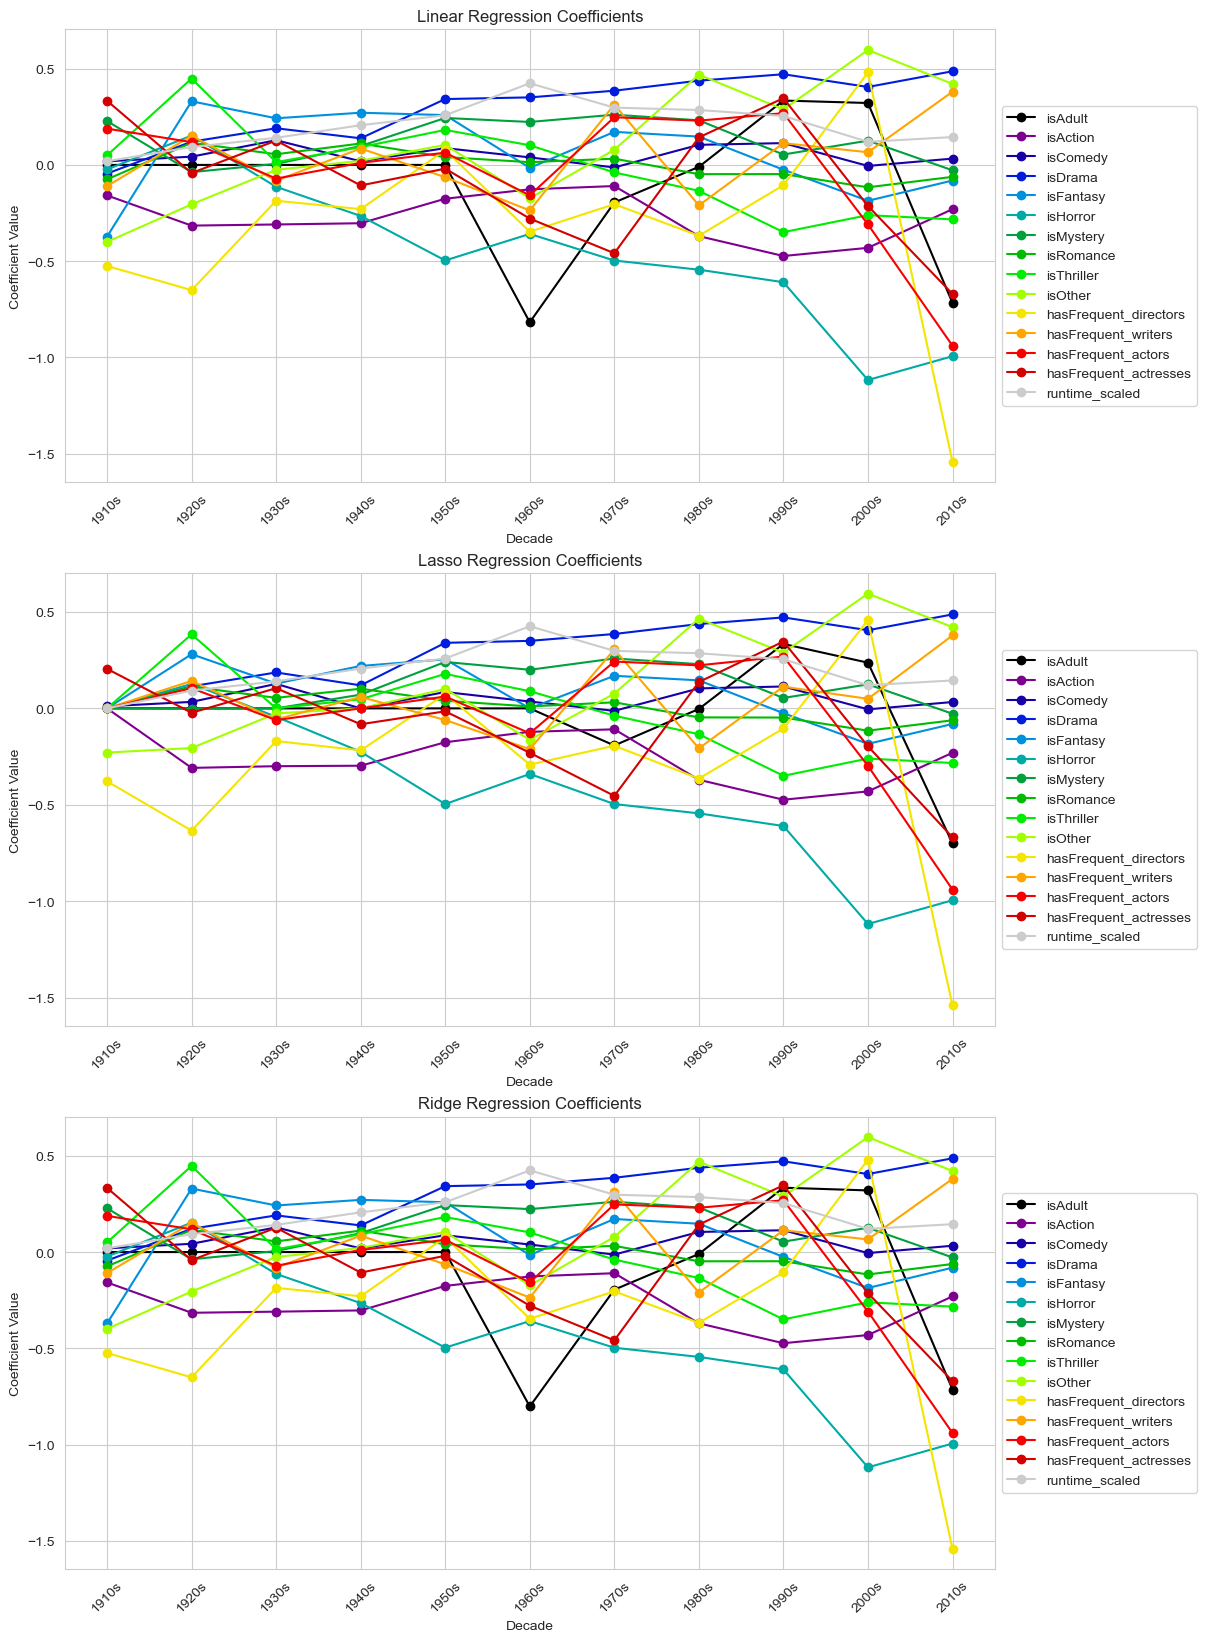

In [35]:
fig, ax = plt.subplots(3, 1, figsize=(12, 20))

predictors = (decade_dict[0].drop(columns=['averageRating', 'runtimeMinutes', 'startYear', 'decade'])).columns
colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(predictors)))

for (pred, color) in zip(predictors, colors):  
    # for each decade plot coefficient value
    ax[0].plot([d[pred] for d in lr_coefs_dec], marker='o', c=color, label=pred)
    ax[0].set_title('Linear Regression Coefficients')
    
    ax[1].plot([d[pred] for d in lasso_coefs_dec], marker='o', c=color, label=pred)
    ax[1].set_title('Lasso Regression Coefficients')
    
    ax[2].plot([d[pred] for d in ridge_coefs_dec], marker='o', c=color, label=pred)
    ax[2].set_title('Ridge Regression Coefficients')

for a in ax:
    a.set_xlabel('Decade')
    a.set_ylabel('Coefficient Value')
    
    a.set_xticks(np.arange(0, 11), labels=decades)
    a.tick_params(axis='x', labelrotation=45)
    a.grid(True)
    a.legend(loc='center left', bbox_to_anchor=(1, 0.5))

Line plots show how the estimated importance of each predictor changes over time and across three modeling approaches. Each line represents a variable’s coefficient value by decade, showing that their influence on IMDb ratings shifts but generally remains small. Some predictors occasionally drop below zero, suggesting a negative association in certain decades, but these variations do not form a clear or stable pattern. The broad clustering of most lines near zero, along with the similarity in trends across the three models, suggests that none of these factors provide a strong or consistent predictive signal for movie ratings on their own. 

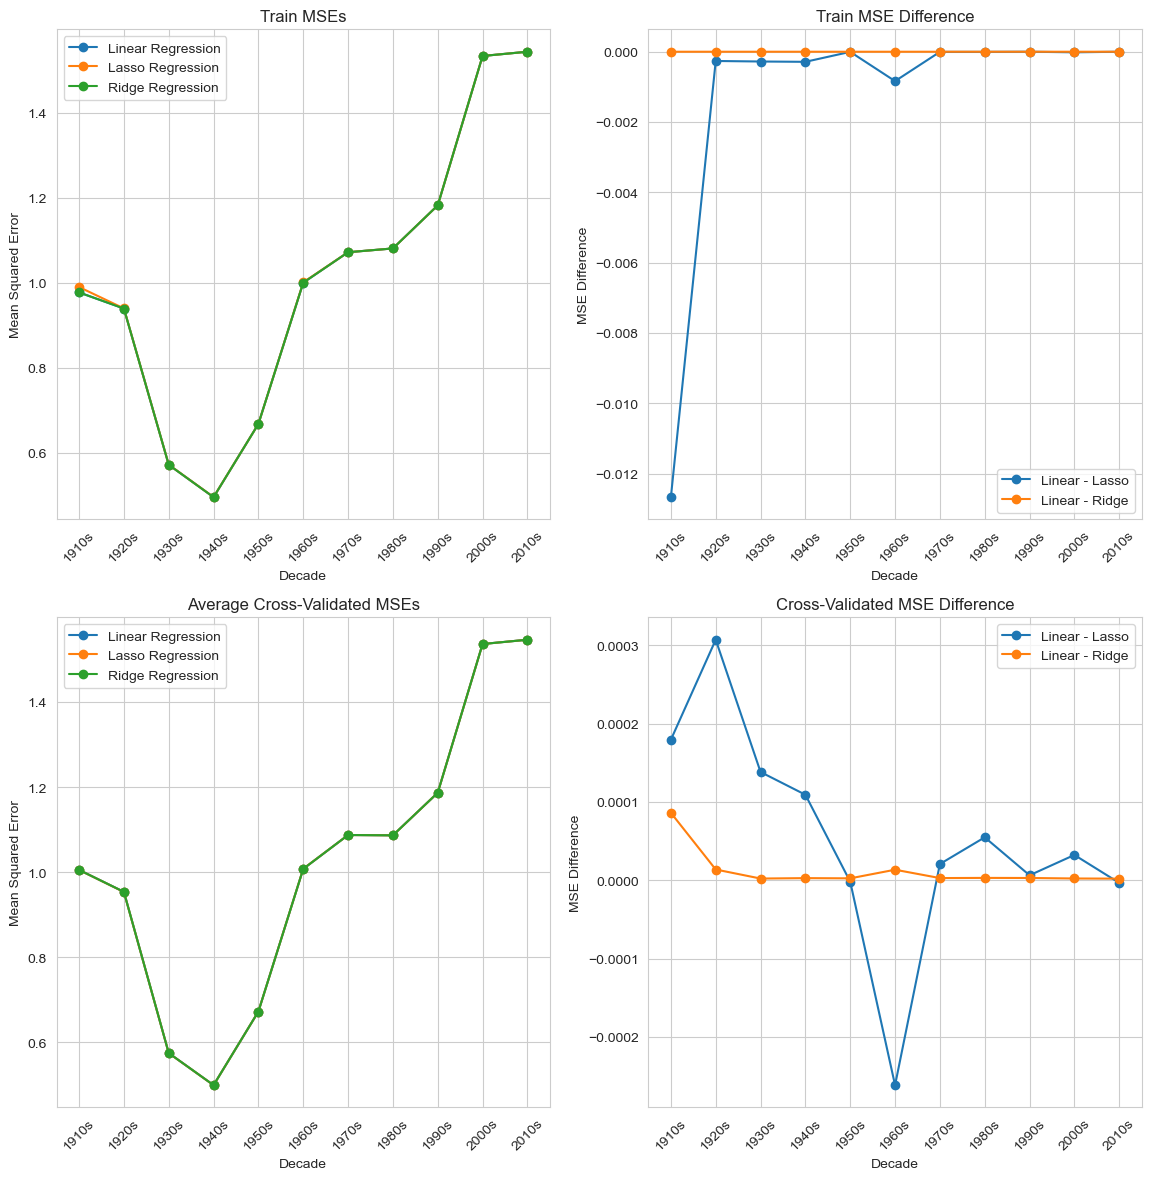

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(14, 14))
ax = ax.ravel()

lr_train_mses = results_df[results_df['name'] == 'Linear Regression']['train_mse'].to_numpy()
lasso_train_mses = results_df[results_df['name'] == 'Lasso Regression']['train_mse'].to_numpy()
ridge_train_mses = results_df[results_df['name'] == 'Ridge Regression']['train_mse'].to_numpy()

lr_cv_mses = results_df[results_df['name'] == 'Linear Regression']['avg_cv_mse'].to_numpy()
lasso_cv_mses = results_df[results_df['name'] == 'Lasso Regression']['avg_cv_mse'].to_numpy()
ridge_cv_mses = results_df[results_df['name'] == 'Ridge Regression']['avg_cv_mse'].to_numpy()

# plot train MSEs for each model
ax[0].plot(lr_train_mses, marker='o', label='Linear Regression')
ax[0].plot(lasso_train_mses, marker='o', label='Lasso Regression')
ax[0].plot(ridge_train_mses, marker='o', label='Ridge Regression')
ax[0].set_title('Train MSEs')
ax[0].set_ylabel('Mean Squared Error')

# plot difference between linear and regularization train MSEs
ax[1].plot(np.subtract(lr_train_mses, lasso_train_mses), marker='o', label='Linear - Lasso')
ax[1].plot(np.subtract(lr_train_mses, ridge_train_mses), marker='o', label='Linear - Ridge')
ax[1].set_title('Train MSE Difference')
ax[1].set_ylabel('MSE Difference')

# plot average cv mse for each model
ax[2].plot(lr_cv_mses, marker='o', label='Linear Regression')
ax[2].plot(lasso_cv_mses, marker='o', label='Lasso Regression')
ax[2].plot(ridge_cv_mses, marker='o', label='Ridge Regression')
ax[2].set_title('Average Cross-Validated MSEs')
ax[2].set_ylabel('Mean Squared Error')

# plot difference between linear and regularization average cv mse
ax[3].plot(np.subtract(lr_cv_mses, lasso_cv_mses), marker='o', label='Linear - Lasso')
ax[3].plot(np.subtract(lr_cv_mses, ridge_cv_mses), marker='o', label='Linear - Ridge')
ax[3].set_title('Cross-Validated MSE Difference')
ax[3].set_ylabel('MSE Difference')

for a in ax:
    a.set_xlabel('Decade')
    a.set_xticks(np.arange(0, 11), labels=decades)
    a.tick_params(axis='x', labelrotation=45)
    a.grid(True)
    a.legend()

The plots show that across different decades all of the regressions yield very similar MSEs, with only small differences in both training and cross-validated performance. Early on, Ridge outperforms the others, likely due to the benefits of regularization in handling noise or collinearity. Over time, however, the advantage diminishes, and by the more recent decades, Ridge performs worse. Meanwhile, Lasso and linear regression results are nearly identical throughout, suggesting that Lasso’s feature selection does not meaningfully improve predictive accuracy over simple linear regression in this setting.

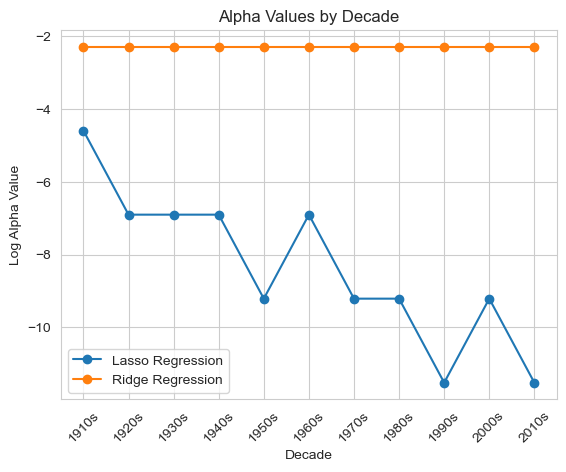

In [37]:
plt.plot(np.log(best_lasso_alphas), marker='o', label='Lasso Regression')
plt.plot(np.log(best_ridge_alphas), marker='o', label='Ridge Regression')
plt.title('Alpha Values by Decade')
plt.ylabel('Log Alpha Value')
plt.xlabel('Decade')
plt.xticks(np.arange(0, 11), labels=decades)
plt.tick_params(axis='x', labelrotation=45)
plt.grid(True)
plt.legend()
plt.show()

The output shows how the chosen alphas for Lasso and Ridge Regression models vary over the decades. The Ridge Regression line is flat at around a log alpha of -2, indicating that Ridge consistently selects a stable, moderate level of regularization. In contrast, the Lasso line shows a steady trend toward increasingly negative log alpha values, meaning it’s selecting smaller and smaller alphas over time, effectively reducing its level of penalization and moving closer to a plain linear model. Ridge’s consistent alpha suggests the model’s preferred balance between complexity and simplicity doesn’t change much, while Lasso’s decreasing alpha values show it’s flexible and quick to reduce regularization when it isn’t adding value.

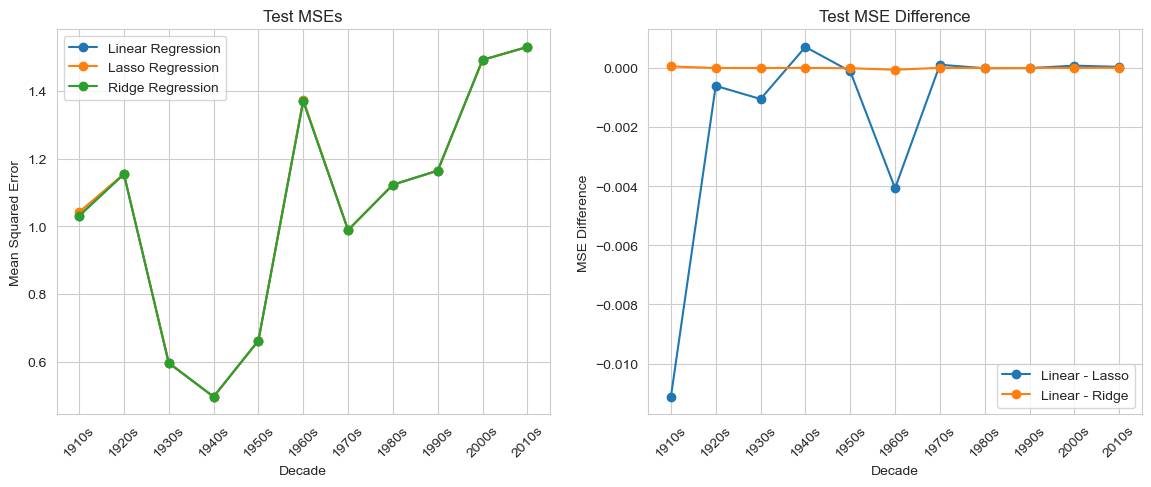

In [38]:
lr_test_mses = results_df[results_df['name'] == 'Linear Regression']['test_mse'].to_numpy()
lasso_test_mses = results_df[results_df['name'] == 'Lasso Regression']['test_mse'].to_numpy()
ridge_test_mses = results_df[results_df['name'] == 'Ridge Regression']['test_mse'].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(lr_test_mses, marker='o', label='Linear Regression')
ax[0].plot(lasso_test_mses, marker='o', label='Lasso Regression')
ax[0].plot(ridge_test_mses, marker='o', label='Ridge Regression')
ax[0].set_title('Test MSEs')
ax[0].set_ylabel('Mean Squared Error')

ax[1].plot(np.subtract(lr_test_mses, lasso_test_mses), marker='o', label='Linear - Lasso')
ax[1].plot(np.subtract(lr_test_mses, ridge_test_mses), marker='o', label='Linear - Ridge')
ax[1].set_title('Test MSE Difference')
ax[1].set_ylabel('MSE Difference')

for a in ax:
    a.set_xlabel('Decade')
    a.set_xticks(np.arange(0, 11), labels=decades)
    a.tick_params(axis='x', labelrotation=45)
    a.grid(True)
    a.legend()

The Test MSE plot on the left shows that all three models stay quite close in performance, with their errors hovering in a similar range across the different decades. Although there's some variance from one decade to the next, these differences probably reflect the inherent characteristics of the data rather than a systematic advantage of one model type over another.

The Difference plot on the right reinforces this similarity. Both Lasso and Ridge yield nearly identical errors compared to the Linear model, with differences that are extremely small—often near zero. This indicates that, given the current set of predictors, regularization neither significantly harms nor improves accuracy relative to standard Linear Regression.

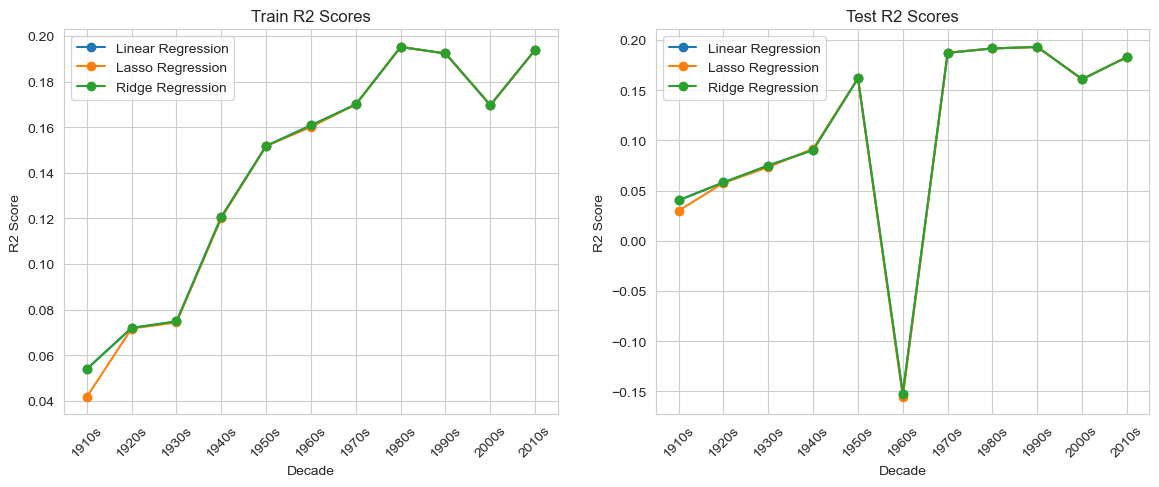

In [39]:
lr_r2_trains = results_df[results_df['name'] == 'Linear Regression']['r2_train'].to_numpy()
lr_r2_tests = results_df[results_df['name'] == 'Linear Regression']['r2_test'].to_numpy()
lasso_r2_trains = results_df[results_df['name'] == 'Lasso Regression']['r2_train'].to_numpy()
lasso_r2_tests = results_df[results_df['name'] == 'Lasso Regression']['r2_test'].to_numpy()
ridge_r2_trains = results_df[results_df['name'] == 'Ridge Regression']['r2_train'].to_numpy()
ridge_r2_tests = results_df[results_df['name'] == 'Ridge Regression']['r2_test'].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(lr_r2_trains, marker='o', label='Linear Regression')
ax[0].plot(lasso_r2_trains, marker='o', label='Lasso Regression')
ax[0].plot(ridge_r2_trains, marker='o', label='Ridge Regression')
ax[0].set_title('Train R2 Scores')
ax[0].set_ylabel('R2 Score')

ax[1].plot(lr_r2_tests, marker='o', label='Linear Regression')
ax[1].plot(lasso_r2_tests, marker='o', label='Lasso Regression')
ax[1].plot(ridge_r2_tests, marker='o', label='Ridge Regression')
ax[1].set_title('Test R2 Scores')
ax[1].set_ylabel('R2 Score')

for a in ax:
    a.set_xlabel('Decade')
    a.set_xticks(np.arange(0, 11), labels=decades)
    a.tick_params(axis='x', labelrotation=45)
    a.grid(True)
    a.legend()

These $R^2$ plots show that apart from 1910s, all three models track very closely together across time. This closeness indicates that once we move beyond the initial decade, there isn’t a pronounced difference between how well these methods explain the variance in movie ratings. Whether on the training set or the test set, the lines overlap substantially, suggesting that these particular predictors lead each model to settle into a similarly modest level of explanatory power.

<a id="scraping"></a>
# Additional Scraping Data
[Return to contents](#contents)

<a id="finscraping"></a>
## Financial Scraping Data

We were intrigued by exploring other response variables for this project. If we are more concerned with company profit and revenue than audience approval, how would this project look different? We developed some code to perform webscraping of IMDb's financial data, however, we ran into some issues. First, there is an ethical consideration. Given that IMDb has a sold dataset product, and we are already using their free Noncommercial Database, there is a valid point to be made that they would prefer us to not scrape their site. Second, the work was compuatationally exepnsive and took too much time. We eventually decided to include the code to show the full extent of our work, but we wanted to acknowledge the importance of these conversations within the notebook. We just found the challenge compelling and wanted to explore its potential. 

We also promise not to make any money off of this project.

The relationship between financial measures and the average rating is positive but noticeably weak, suggesting that while higher-grossing movies often have slightly better ratings, this connection is of course not nearly as strong as the financial interrelationships. Also, the start year of the movie shows relatively low correlations with both financial and rating metrics, indicating that neither a movie’s earnings nor its reception is strongly tied to the particular year it was released.

In [40]:
import pickle
import scrapy
from scrapy.crawler import CrawlerProcess
from scrapy.utils.project import get_project_settings
import os
from scipy.stats import pearsonr, spearmanr, linregress

In [41]:
# convert startYear to numeric and filter
df_titlebasics['startYear'] = pd.to_numeric(df_titlebasics['startYear'], errors='coerce')
# df_titlebasics = df_titlebasics[df_titlebasics['titleType'] == 'movie']
df_titlebasics = df_titlebasics[df_titlebasics['startYear'].between(1980, 2019)]

# US and English only
df_titleakas = df_titleakas[(df_titleakas['region'] == 'US') & (df_titleakas['language'] == 'en')]

# merge to keep only matches
df_merged = df_titlebasics.merge(df_titleakas, left_on='tconst', right_on='titleId', how='inner')
df_merged = df_merged.merge(df_titleprincipals, on='tconst', how='inner')
df_merged = df_merged.merge(df_titleratings, on='tconst', how='inner')

tconst_list = df_merged['tconst'].unique()

# save tconst list
with open('my_data.pkl', 'wb') as picklefile:
    pickle.dump(tconst_list, picklefile)

In [42]:
class IMDBSpider(scrapy.Spider):
    name = 'imdb_spider'
    custom_settings = {
        "CONCURRENT_REQUESTS_PER_DOMAIN": 3,
        "AUTOTHROTTLE_ENABLED": True,
        "AUTOTHROTTLE_START_DELAY": 0,
        "AUTOTHROTTLE_MAX_DELAY": 0,
        "DEFAULT_REQUEST_HEADERS": {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:90.0) Gecko/20100101 Firefox/90.0'
        },
        "HTTPCACHE_ENABLED": False,
        "FEEDS": {
            "output.json": {"format": "json"}
        }
    }

    def __init__(self, *args, **kwargs):
        super(IMDBSpider, self).__init__(*args, **kwargs)
        with open("my_data.pkl", 'rb') as picklefile:
            self.links = list(pickle.load(picklefile))

    def start_requests(self):
        base_url = 'https://www.imdb.com/title/'
        for l in self.links:
            url = f"{base_url}{l}/"
            yield scrapy.Request(url, callback=self.parse, meta={'title_id': l})

    def parse(self, response):
        if response.status == 403:
            self.logger.warning(f"Access forbidden for {response.url}")
            return

        title_id = response.meta['title_id']
        title = response.xpath('//h1[@data-testid="hero__pageTitle"]//span[@data-testid="hero__primary-text"]/text()').get()

        budget = response.xpath('//li[@data-testid="title-boxoffice-budget"]//span[@class="ipc-metadata-list-item__list-content-item"]/text()').get()
        opening = response.xpath('//li[@data-testid="title-boxoffice-openingweekenddomestic"]//span[@class="ipc-metadata-list-item__list-content-item"]/text()').get()
        gross_us_canada = response.xpath('//li[@data-testid="title-boxoffice-grossdomestic"]//span[@class="ipc-metadata-list-item__list-content-item"]/text()').get()
        worldwide_gross = response.xpath('//li[@data-testid="title-boxoffice-cumulativeworldwidegross"]//span[@class="ipc-metadata-list-item__list-content-item"]/text()').get()

        def clean_numeric(value):
            if value:
                value = value.replace('$', '').replace(',', '').strip()
                value = re.sub(r'\(.*?\)', '', value).strip()
                return value
            return None

        budget = clean_numeric(budget)
        opening = clean_numeric(opening)
        gross_us_canada = clean_numeric(gross_us_canada)
        worldwide_gross = clean_numeric(worldwide_gross)

        # only yield if at least one financial field is present
        if not any([budget, opening, gross_us_canada, worldwide_gross]):
            return

        self.logger.info(f"Found financial data for: {title} (ID: {title_id})")

        yield {
            'title_id': title_id,
            'title': title,
            'budget': budget,
            'opening': opening,
            'gross_us_canada': gross_us_canada,
            'worldwide_gross': worldwide_gross
        }

In [43]:
process = CrawlerProcess(settings={
    "FEEDS": {
        "output.json": {"format": "json"}
    }
})
process.crawl(IMDBSpider)
process.start()

2024-12-16 20:12:01 [scrapy.utils.log] INFO: Scrapy 2.12.0 started (bot: scrapybot)
2024-12-16 20:12:01 [scrapy.utils.log] INFO: Versions: lxml 5.3.0.0, libxml2 2.12.7, cssselect 1.2.0, parsel 1.9.1, w3lib 2.2.1, Twisted 24.11.0, Python 3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)], pyOpenSSL 24.3.0 (OpenSSL 3.4.0 22 Oct 2024), cryptography 44.0.0, Platform Windows-10-10.0.19045-SP0
2024-12-16 20:12:01 [scrapy.addons] INFO: Enabled addons:
[]
2024-12-16 20:12:01 [scrapy.utils.log] DEBUG: Using reactor: twisted.internet.selectreactor.SelectReactor
2024-12-16 20:12:01 [scrapy.extensions.telnet] INFO: Telnet Password: e911a274c53eb1c1
2024-12-16 20:12:01 [scrapy.middleware] INFO: Enabled extensions:
['scrapy.extensions.corestats.CoreStats',
 'scrapy.extensions.telnet.TelnetConsole',
 'scrapy.extensions.feedexport.FeedExporter',
 'scrapy.extensions.logstats.LogStats',
 'scrapy.extensions.throttle.AutoThrottle']
2024-12-16 20:12:01 [scrapy.craw

In [44]:
# should show a list of movie ids
with open("my_data.pkl", 'rb') as f:
    data = pickle.load(f)
print(data)

['tt0080263' 'tt0080319' 'tt0080684' ... 'tt9850370' 'tt9909874'
 'tt9910024']


In [45]:
df_financial = pd.read_json("output.json")
df_financial.head()

,title_id,title,budget,opening,gross_us_canada,worldwide_gross
0,tt0080319,9 to 5,10000000,3966832.0,103290500.0,103303454
1,tt0080684,Star Wars: Episode V - The Empire Strikes Back,18000000,4910483.0,292753960.0,550016086
2,tt0080707,The Exterminator,2000000,NaN,NaN,None
3,tt0080889,Hopscotch,9500000,NaN,NaN,None
4,tt0081059,Lion of the Desert,35000000,NaN,NaN,None


<a name="finsummary"></a>
#### Basic Summary

In [46]:
df_financial = pd.read_json('output.json')

financial_cols = ['budget', 'opening', 'gross_us_canada', 'worldwide_gross']

df_financial[financial_cols] = df_financial[financial_cols].apply(pd.to_numeric, errors='coerce')

print("Summary Statistics:")
print(df_financial[financial_cols].describe())

Summary Statistics:
             budget       opening  gross_us_canada  worldwide_gross
count  4.740000e+02  3.320000e+02     3.510000e+02     4.580000e+02
mean   2.704920e+07  1.902235e+07     6.630177e+07     1.185566e+08
std    5.177667e+07  4.144054e+07     1.269035e+08     2.966807e+08
min    1.000000e+01  9.000000e+01     7.040000e+02     1.840000e+02
25%    5.000000e+05  5.034125e+04     3.594095e+05     3.243480e+05
50%    4.500000e+06  3.168584e+06     1.127712e+07     6.788336e+06
75%    2.500000e+07  1.674642e+07     6.485612e+07     7.572958e+07
max    3.560000e+08  3.571150e+08     8.583730e+08     2.799439e+09


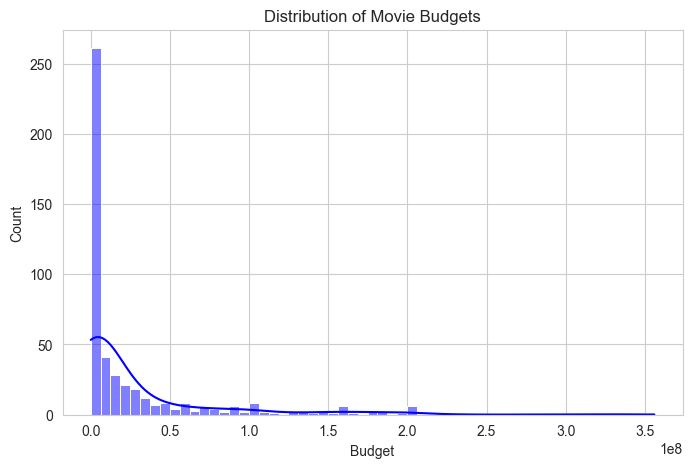

In [47]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 5))
sns.histplot(df_financial['budget'], kde=True, color='blue')
plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget")
plt.ylabel("Count")
plt.show()

This distribution shows that most films operate with relatively modest budgets, clustering heavily at the lower end of the financial spectrum, while only a few titles secure the kind of funding that goes into the tens or hundreds of millions. This right skewed pattern shows that high budget productions are rare outlierxs.

Pearson Correlation between averageRating and log(worldwide_gross):
Correlation: 0.366, p-value: 3.045e-317

Spearman Correlation between averageRating and log(worldwide_gross):
Correlation: 0.378, p-value: 0.000e+00

Linear Regression Results (log_worldwide_gross ~ averageRating):
Slope: 1.045
Intercept: 8.896
R-squared: 0.134
p-value: 0.000e+00
Std. Error: 0.026


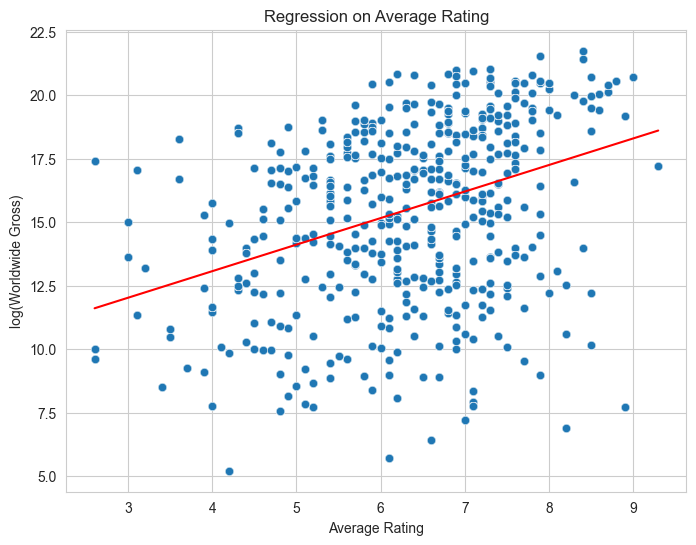

In [48]:
df_merged = df_merged.merge(df_financial[['title_id', 'worldwide_gross']], left_on='tconst', right_on='title_id', how='left')
df_merged.drop(columns='title_id', inplace=True)

rating_data = df_merged.dropna(subset=['averageRating','worldwide_gross']).copy()

# log transform 
rating_data['log_worldwide_gross'] = np.log(rating_data['worldwide_gross'])

# pearson correlation
pearson_corr, pearson_p = pearsonr(rating_data['averageRating'], rating_data['log_worldwide_gross'])
print("Pearson Correlation between averageRating and log(worldwide_gross):")
print(f"Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.3e}")

# spearman correlation
spearman_corr, spearman_p = spearmanr(rating_data['averageRating'], rating_data['log_worldwide_gross'])
print("\nSpearman Correlation between averageRating and log(worldwide_gross):")
print(f"Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.3e}")

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(rating_data['averageRating'], rating_data['log_worldwide_gross'])
print("\nLinear Regression Results (log_worldwide_gross ~ averageRating):")
print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R-squared: {r_value**2:.3f}")
print(f"p-value: {p_value:.3e}")
print(f"Std. Error: {std_err:.3f}")

plt.figure(figsize=(8,6))
sns.scatterplot(x='averageRating', y='log_worldwide_gross', data=rating_data, alpha=0.5)
x_vals = np.linspace(rating_data['averageRating'].min(), rating_data['averageRating'].max(), 100)
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color='red')
plt.title("Regression on Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("log(Worldwide Gross)")
plt.show()


These results indicate a modest yet statistically significant positive relationship between a movie’s average rating and its worldwide gross. Both the Pearson and Spearman correlations are positive and have very low p-values, suggesting that better rated movies tend to earn more, even after taking a logarithmic transformation of worldwide gross to stabilize the scale.

However, while the relationship is not trivial, it’s not extremely strong: the R-squared value is about 0.114, meaning that average rating explains only around 11% of the variance in log-transformed worldwide gross. In other words, although higher ratings are associated with higher earnings, many other factors must influence a film’s financial performance. The scatter plot visually confirms this: the trend line slopes upward, but the points remain broadly scattered.

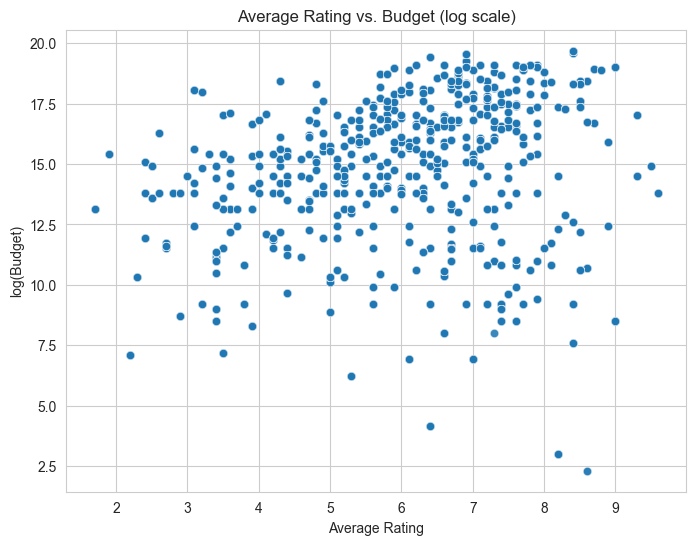

Pearson Correlation between averageRating and log(budget):
Correlation: 0.310, p-value: 4.779e-218

Spearman Correlation between averageRating and log(budget):
Correlation: 0.374, p-value: 0.000e+00

Linear Regression Results (log_budget ~ averageRating):
Slope: 0.558
Intercept: 11.878
R-squared: 0.096
p-value: 4.779e-218
Std. Error: 0.017


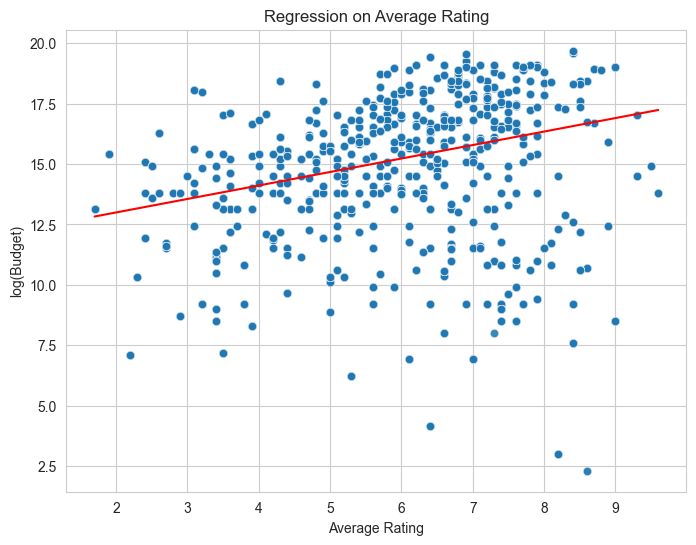

In [49]:
# merge the df_financial df into df_merged to add budget data
df_merged = df_merged.merge(df_financial[['title_id', 'budget']], left_on='tconst', right_on='title_id', how='left')

# remove the redundant title_id column after merging
df_merged.drop(columns='title_id', inplace=True)

if 'budget' not in df_merged.columns or 'averageRating' not in df_merged.columns:
    print("Either 'budget' or 'averageRating' is not available in df_merged.")
else:
    # create a copy of the df with both budget and averageRating
    rating_data = df_merged.dropna(subset=['budget', 'averageRating']).copy()

    # filter to include only entries with a positive budget
    rating_data = rating_data[rating_data['budget'] > 0]

    # add a column for the log transformed budget
    rating_data['log_budget'] = np.log(rating_data['budget'])

    plt.figure(figsize=(8,6))
    sns.scatterplot(x='averageRating', y='log_budget', data=rating_data, alpha=0.5)
    plt.title("Average Rating vs. Budget (log scale)")
    plt.xlabel("Average Rating")
    plt.ylabel("log(Budget)")

    plt.show()

    # pearson 
    pearson_corr, pearson_p = pearsonr(rating_data['averageRating'], rating_data['log_budget'])
    print("Pearson Correlation between averageRating and log(budget):")
    print(f"Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.3e}")

    # spearman
    spearman_corr, spearman_p = spearmanr(rating_data['averageRating'], rating_data['log_budget'])
    print("\nSpearman Correlation between averageRating and log(budget):")
    print(f"Correlation: {spearman_corr:.3f}, p-value: {spearman_p:.3e}")

    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(rating_data['averageRating'], rating_data['log_budget'])
    print("\nLinear Regression Results (log_budget ~ averageRating):")
    print(f"Slope: {slope:.3f}")
    print(f"Intercept: {intercept:.3f}")
    print(f"R-squared: {r_value**2:.3f}")
    print(f"p-value: {p_value:.3e}")
    print(f"Std. Error: {std_err:.3f}")

    # plot regression line
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='averageRating', y='log_budget', data=rating_data, alpha=0.5)
    x_vals = np.linspace(rating_data['averageRating'].min(), rating_data['averageRating'].max(), 100)
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, color='red')
    plt.title("Regression on Average Rating")
    plt.xlabel("Average Rating")
    plt.ylabel("log(Budget)")
    plt.show()


These results indicate a weaker but still statistically significant positive relationship between a movie’s average rating and its budget. The Pearson correlation is about 0.203 and the Spearman correlation is about 0.271, both with very small p-values, suggesting that higher-rated films tend to have somewhat higher budgets. However, the R-squared value from the linear regression is only about 0.041, indicating that average rating accounts for just over 4% of the variation in log-transformed budgets. In other words, while there is a noticeable tendency for better rated movies to have larger budgets, the effect is not particularly strong.

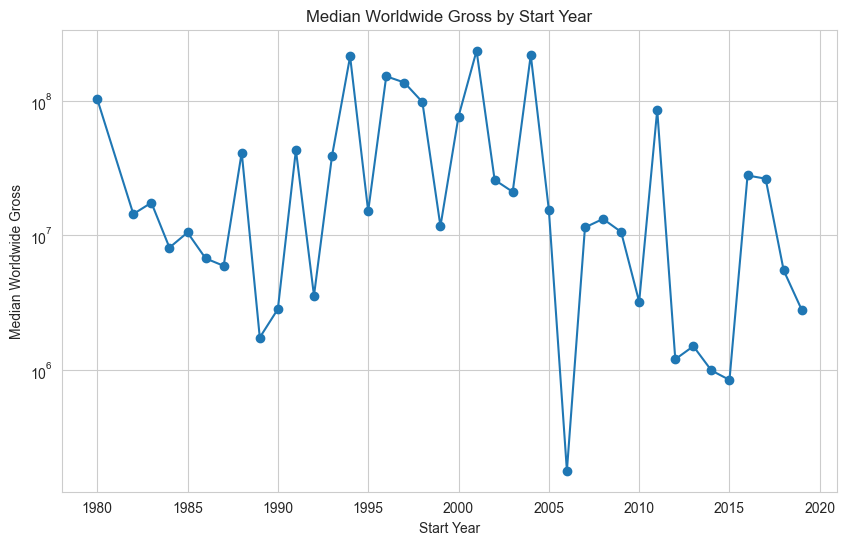

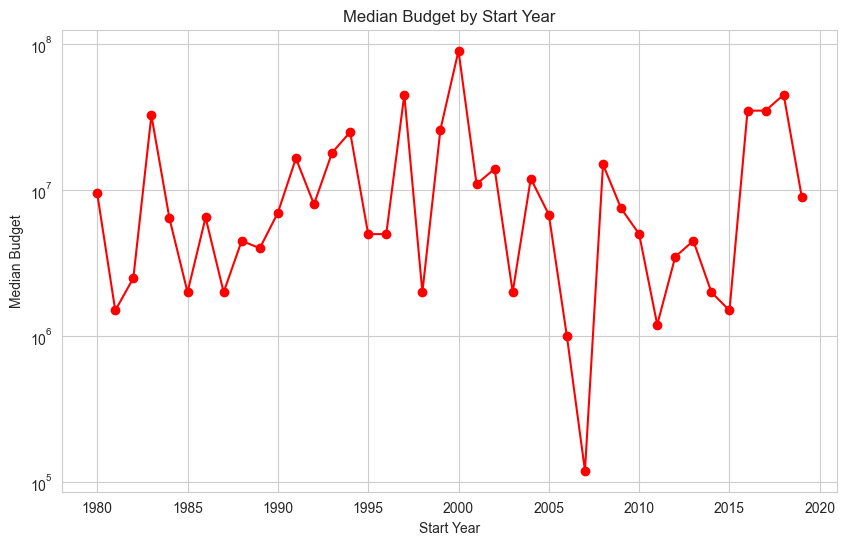

In [50]:
# disable debug logging to avoid tons of output
logging.disable(logging.DEBUG)

if 'startYear' in df_merged.columns:
    year_gross = df_merged.dropna(subset=['worldwide_gross', 'startYear'])

    # median worldwide gross for each start year
    median_gross_by_year = year_gross.groupby('startYear')['worldwide_gross'].median()
    
    # Plot the median worldwide gross by year
    plt.figure(figsize=(10,6))
    median_gross_by_year.plot(kind='line', marker='o')
    plt.title("Median Worldwide Gross by Start Year")
    plt.xlabel("Start Year")
    plt.ylabel("Median Worldwide Gross")
    plt.yscale('log')
    plt.show()

    year_budget = df_merged.dropna(subset=['budget', 'startYear'])

    # median budget for each start tyear 
    median_budget_by_year = year_budget.groupby('startYear')['budget'].median()

    # Plot the median budget by year
    plt.figure(figsize=(10,6))
    median_budget_by_year.plot(kind='line', marker='o', color='red')
    plt.title("Median Budget by Start Year")
    plt.xlabel("Start Year")
    plt.ylabel("Median Budget")
    plt.yscale('log')
    plt.show()


The plots show the year-to-year fluctuations in median financial metrics (worldwide gross and budget) of movies. Both metrics are plotted on a logarithmic scale to better handle the wide range of values, and neither appears to follow a simple, consistent upward or downward trajectory over time. Instead, the median values are volatile, reflecting substantial year to year variability. 

For median worldwide gross, some years see median values approach or exceed 10^8, while others dip down toward 10^6 or 10^7. Similarly, median budgets also experience large swings, sometimes rising above 10^8 and other times dropping near 10^5. This patterns suggest that the composition of movies released each year, including factors like production scale, distribution practices, and the nature of the films measured, can vary greatly. In other words, the data reveal no clear long term trend, but rather a shifting landscape, year to year, in the kinds of movies produced and their financial performance.

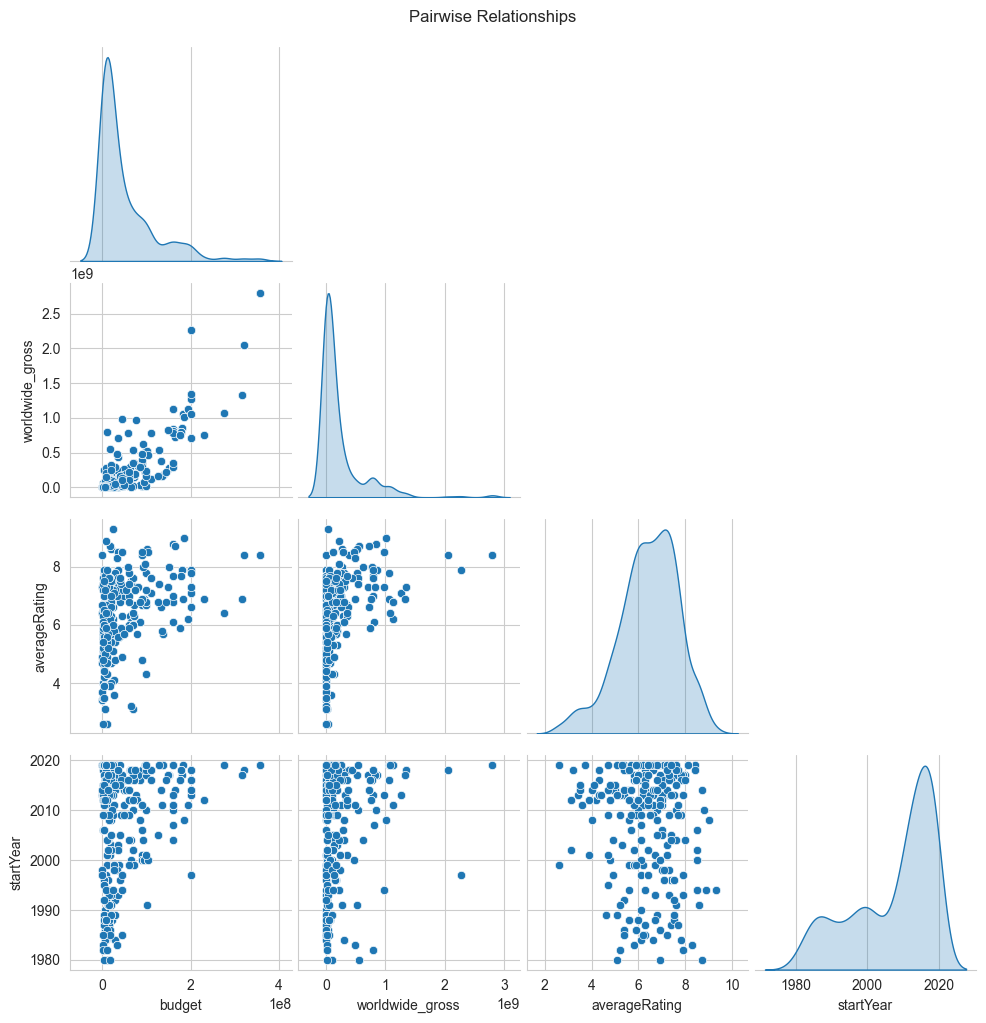

In [51]:
extra_cols = []

if 'averageRating' in df_merged.columns:
    extra_cols.append('averageRating')

if 'startYear' in df_merged.columns:
    extra_cols.append('startYear')

# combine the financial columns with the extra columns
cols_for_pair = financial_cols + extra_cols

# filter the columns
cols_for_pair = [c for c in cols_for_pair if c in df_merged.columns]

if len(cols_for_pair) > 1:
    # drop rows with missing values in these columns
    sampled_df = df_merged[cols_for_pair].dropna()
    
    # limit the sample size to 1000
    sample_size = min(len(sampled_df), 1000)
    
    if sample_size > 0:
        # randomly sample the data to speed up pairplot creation on large datasets
        sampled = sampled_df.sample(sample_size, random_state=42)
        
        sns.pairplot(sampled, corner=True, diag_kind='kde')
        
        plt.suptitle("Pairwise Relationships", y=1.02)
        plt.show()
    else:
        print("No sufficient data")


Focusing on the relationship between average rating and the financial variables, we see a weaker positive association than among the financial metrics themselves. Although the scatterplots show that as average rating increases, there is some tendency for budget and worldwide gross to rise, the relationship is much more scattered, with many movies achieving high grosses or substantial budgets even at moderate rating levels. The patterns suggest that while better rated films may be somewhat more likely to have higher budgets or earnings, a movie’s popularity with critics or audiences isn’t a straightforward predictor of its financial success. Instead, ratings appear to be just one of many factors influencing a film’s budget and box office performance.

<a name="actorscraping"></a>
## Actor Scraping Data

In [48]:
# example using Cinemagoer – Dunkirk
ia = Cinemagoer()

movie_title = '5013056'
movie = ia.get_movie(movie_title)

# Get the movie ID
if movie:
    # movie_id = movies[0].movieID
    # movie = ia.get_movie(movie_id)

    # get directors
    directors = movie.get('directors')
    # Print the directors
    directors_string = ''
    print("Directors in", movie, ":")
    for director in directors:
        # print(director['name'])
        if (directors_string == ''):
            directors_string += director['name']
        else:
            directors_string += (', ' + director['name'])

    # Get the cast
    cast = movie.get('cast')
    # Print the actors
    actors_string = ''
    print("Actors in", movie, ":")
    for actor in cast:
        # print(actor['name'])
        if (actors_string == ''):
            actors_string += actor['name']
        else:
            actors_string += (', ' + actor['name'])

    # Get the writers
    writers = movie.get('writers')
    # Print the actors
    writers_string = ''
    print("Writers in", movie, ":")
    for writer in writers:
        # print(writer['name'])
        if (writers_string == ''):
            writers_string += writer['name']
        else:
            writers_string += (', ' + writer['name'])
else:
    print("Movie not found.")

print('output:')
print(directors_string)
print(actors_string)

Directors in Dunkirk :
Actors in Dunkirk :
Writers in Dunkirk :
output:
Christopher Nolan
Fionn Whitehead, Damien Bonnard, Aneurin Barnard, Lee Armstrong, James Bloor, Barry Keoghan, Mark Rylance, Tom Glynn-Carney, Tom Hardy, Jack Lowden, Luke Thompson, Michel Biel, Constantin Balsan, Billy Howle, Mikey Collins, Callum Blake, Dean Ridge, Bobby Lockwood, Will Attenborough, Kenneth Branagh, Tom Nolan, James D'Arcy, Matthew Marsh, Cillian Murphy, Adam Long, Harry Styles, Miranda Nolan, Bradley Hall, Jack Cutmore-Scott, Brett Lorenzini, Michael Fox, Brian Vernel, Elliott Tittensor, Kevin Guthrie, Harry Richardson, Jochum ten Haaf, Johnny Gibbon, Richard Sanderson, Kim Hartman, Calam Lynch, Charley Palmer Rothwell, Tom Gill, John Nolan, Bill Milner, Jack Riddiford, Harry Collett, Eric Richard, Glyn Angell, Sam Aronow, Simon Ates, Caleb Bailey, Sander Blom, Wilhelm Bonnelle, Michael Caine, Hugo-Vincent Couturier, Sam Dacombe, R.A. Donnelly, Dennis Eleveld, Paul Riley Fox, Melvin Garcia, Jack

In [50]:
# add actor and director information for each film (~320,000 films)
actors_list = []
directors_list = []

ia = Cinemagoer()

for index, row in df_recentmovies.iterrows():
    if row['tconst'][0].startswith('tt'):
        # get movie info
        movie = ia.get_movie(row['tconst'][0][2:])

        if movie:
            # get directors
            directors = movie.get('directors')
            # Print the directors
            directors_string = ''
            # print("Directors in", movie, ":")
            if directors:
                for director in directors:
                    # print(director['name'])
                    if (directors_string == ''):
                        directors_string += director['name']
                    else:
                        directors_string += (', ' + director['name'])
            # Get the cast
            cast = movie.get('cast')
            # Print the actors
            actors_string = ''
            # print("Actors in", movie, ":")
            if cast:
                for actor in cast:
                    # print(actor['name'])
                    if (actors_string == ''):
                        actors_string += actor['name']
                    else:
                        actors_string += (', ' + actor['name'])
    
            actors_list.append(actors_string)
            directors_list.append(directors_string)
        else: 
            actors_list.append(None)
            directors_list.append(None)
    else:
        actors_list.append(None)
        directors_list.append(None)

/var/folders/gk/sqys7s8s6dng3rkfrl979xtr0000gn/T/ipykernel_32689/268858955.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row['tconst'][0].startswith('tt'):
/var/folders/gk/sqys7s8s6dng3rkfrl979xtr0000gn/T/ipykernel_32689/268858955.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movie = ia.get_movie(row['tconst'][0][2:])
